# Прогнозирование цен на недвижимость (Россия) — сквозной ML-пайплайн

**Демонстрационный учебный проект: EDA, статистический анализ, feature engineering и сравнение моделей.**

## Об этом ноутбуке

Автор проекта: учебный портфолио-проект по анализу данных и ML.

Ноутбук — основной аналитический артефакт проекта
`real-estate-price-prediction`. Он не содержит личных данных, абсолютных
путей файловой системы или учётных данных — все пути заданы относительно
корня проекта.

> **Важно с первой строки:** все данные и метрики в этом ноутбуке получены
> на **синтетических демонстрационных данных** (200 строк), а не на
> реальных объявлениях ЦИАН. Каждый раздел, где приводятся числа, явно
> напоминает об этом. Подробности — в разделе 5 и в `DATA_CARD.md`.

## 1. Цели проекта

1. Показать полный цикл ML-проекта на данных о недвижимости: от аудита
   данных и очистки — до обучения нескольких моделей и содержательного
   сравнения с базовыми решениями (baselines).
2. Продемонстрировать корректные инженерные практики: разделение
   train/test без утечек, честную статистическую проверку гипотез,
   воспроизводимость (фиксированный `random_state`), переиспользование
   production-кода (`src/`) вместо дублирования логики в ноутбуке.
3. Быть **честным** учебным артефактом: явно и многократно обозначать, что
   единственный доступный источник данных — синтетический генератор, а не
   реальный рынок недвижимости.

## 2. Задачи ноутбука

- Загрузить и провести первичный аудит инженерного датасета.
- Очистить данные, переиспользуя `src.preprocessing.cleaner.DataCleaner`.
- Провести разведочный анализ (EDA) с визуализациями и текстовыми выводами
  после каждого раздела.
- Сформулировать и проверить статистические гипотезы (с поправкой на
  множественные сравнения), сохранить результаты в
  `reports/statistical_tests.csv` и `reports/STATISTICAL_ANALYSIS.md`.
- Построить признаки через `src.features.feature_engineering.FeatureEngineer`
  и явно проверить отсутствие утечек (leakage).
- Реализовать несколько baseline-решений и несколько «настоящих» моделей ML
  в едином, воспроизводимом протоколе оценки, сохранить сравнение в
  `reports/model_comparison.csv` и `reports/MODEL_EXPERIMENTS.md`.
- Выбрать лучшую модель, разобрать её ошибки, оценить важность признаков,
  проверить устойчивость к смене `random_state`.
- Сформулировать честные ограничения, выводы и дорожную карту.

## 3. Постановка задачи (бизнес + ML)

**Бизнес-задача.** Оценить рыночную стоимость квартиры по её характеристикам
(город, площадь, этаж, тип дома, год постройки и т.д.), чтобы дать
пользователю (покупателю, продавцу или внутреннему сервису) быструю
ориентировочную оценку цены без ручного анализа объявлений.

**ML-задача.** Регрессия: предсказать `price` (цена объявления, ₽) по
табличным признакам квартиры и макроэкономическим показателям на момент
публикации объявления. Целевая переменная логарифмируется (`log1p(price)`)
для обучения моделей, а все итоговые бизнес-метрики (MAE, RMSE, MAPE)
приводятся обратно в рубли перед сравнением.

**Потребитель результата.** В этом же репозитории задача интегрирована в
FastAPI-сервис (`api/`) и Streamlit-дашборд (`dashboard/`) — см. раздел 26
«Продакшн-контекст».

## 4. Критерии успеха

Так как единственные доступные данные — синтетические (раздел 5), нельзя
заявлять о «промышленной точности» модели. Критерии успеха для этого
демонстрационного прохода:

1. **Методологическая корректность**: baseline-модели явно превосходятся
   «настоящими» моделями на одном и том же протоколе оценки; отсутствие
   утечек данных доказано явными проверками, а не декларацией.
2. **Статистическая строгость**: гипотезы проверяются подходящими тестами
   (с проверкой предпосылок — нормальности/дисперсий) и с поправкой на
   множественные сравнения, а не «дефолтным t-тестом».
3. **Воспроизводимость**: фиксированный `random_state=42` везде, явные
   относительные пути, детерминированный порядок ячеек, ноутбук
   выполняется от начала до конца без ошибок.
4. **Честность**: ни один результат не выдаётся за описание реального
   рынка недвижимости.

## 5. Источник данных

Дословная выдержка из `DATA_CARD.md` (актуальный источник истины по
происхождению данных в этом проекте):

> **No real CIAN listing data has ever been collected or used in this
> project.** Every dataset and model artefact currently on disk or
> referenced by default commands is **synthetic demo data** generated by
> `scripts/run_feature_engineering_real.py::_generate_synthetic_data()`.

Иными словами:

- Используемый файл — `data/processed/real_estate_engineered.synthetic.csv`
  (200 строк), сгенерированный функцией `_generate_synthetic_data(n=200,
  seed=42)`.
- Адреса — заглушки (`"ул. Примерная, д. N, <город>"`), URL — последовательные
  фиктивные ссылки (`https://cian.ru/sale/flat/100000+i/`).
- В датафрейме есть явный флаг `is_synthetic=True` для каждой строки —
  ноутбук проверяет его при загрузке (раздел 9).
- Цена сгенерирована формулой вида `price ≈ base_price_per_sqm[город] ×
  площадь × шум`, то есть зависимости в данных отражают **логику
  генератора**, а не реальное ценообразование рынка недвижимости.
- Реальный скрапинг ЦИАН (`src/data_collection/cian_scraper.py`) в рамках
  этого прохода не запускался — см. раздел 29 «Дорожная карта».

**Каждая метрика и каждый вывод ниже по тексту описывают поведение
синтетического генератора, а не реальный рынок.**

## 6. Ограничения данных и этические аспекты

- **Синтетичность — главное ограничение.** Любая корреляция или различие,
  найденные ниже, являются свойством генератора (`_generate_synthetic_data`),
  а не рынка недвижимости. Подробнее — раздел 27.
- **Размер выборки.** 200 строк, из них ~40 в отложенной (holdout) выборке —
  очень маленький объём для регрессии с 27 признаками; p-value и интервалы
  нужно интерпретировать с осторожностью.
- **Персональные данные.** В синтетических данных нет персональных данных
  реальных людей (адреса и URL — вымышленные). Если/когда будет собран
  реальный датасет с ЦИАН, объявления являются публичными рекламными
  объявлениями, а не персональными данными физлиц, но массовое
  распространение сырых данных всё равно не предполагается (см.
  `DATA_CARD.md`, раздел «Limitations and ethical/legal notes»).
- **Раскрытие в продакшене.** Все точки выдачи предсказаний (API, дашборд)
  обязаны явно показывать пользователю метку demo/synthetic — уже
  реализовано в `dashboard/app.py` (бейдж DEMO/ML-режим).

## Настройка окружения (imports, параметры, пути)

Импорты сгруппированы в одной ячейке. Пути — только относительные
(вычисляются от расположения ноутбука), без абсолютных Windows-путей и
имени пользователя. Все случайные генераторы зафиксированы `RANDOM_STATE=42`
для воспроизводимости.

In [1]:
# --- Стандартная библиотека -------------------------------------------------
import sys
import time
import warnings
from pathlib import Path

# --- Научный стек ------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

# --- scikit-learn / xgboost / catboost ---------------------------------------
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import joblib

# LightGBM намеренно НЕ импортируется: пакет не установлен в этом окружении,
# а `pip install lightgbm` был явно заблокирован песочницей агента в этой
# сессии — задокументированное ограничение среды, а не решение пропустить
# модель без причины (см. раздел 16 и reports/MODEL_EXPERIMENTS.md).

# --- Проектные модули (переиспользуем production-код, не дублируем его) -----
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing.cleaner import DataCleaner
from src.features.feature_engineering import (
    BUILDING_TYPE_ONEHOT_COLUMNS,
    CITY_ONEHOT_COLUMNS,
    FeatureEngineer,
)
from src.models.trainer import ModelTrainer, compute_residual_quantile_interval

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

# --- Параметры проекта --------------------------------------------------------
RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 5
ALPHA = 0.05  # уровень значимости для статистических тестов

np.random.seed(RANDOM_STATE)

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "real_estate_engineered.synthetic.csv"
REPORTS_DIR = PROJECT_ROOT / "reports"
MODELS_DIR = PROJECT_ROOT / "models"
ASSETS_DIR = PROJECT_ROOT / "notebooks" / "assets"

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.unicode_minus"] = False

print(f"PROJECT_ROOT = {PROJECT_ROOT.name} (относительный корень определён)")
print(f"DATA_PATH exists: {DATA_PATH.exists()}")

PROJECT_ROOT = real-estate-price-prediction (относительный корень определён)
DATA_PATH exists: True


## 7. Загрузка данных

Загружаем инженерный синтетический датасет по относительному пути. Если файл
отсутствует, ноутбук **не генерирует данные сам** — он останавливается с
понятной инструкцией, какую команду пайплайна нужно запустить.

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Не найден файл с данными: {DATA_PATH}\n\n"
        "Ноутбук намеренно НЕ генерирует данные сам. Чтобы создать "
        "демонстрационный (синтетический) датасет, выполните из корня проекта:\n"
        "    make demo-data\n"
        "или эквивалентно:\n"
        "    python scripts/run_feature_engineering_real.py --allow-synthetic\n"
    )

raw_df = pd.read_csv(DATA_PATH)

assert "is_synthetic" in raw_df.columns, "Ожидался явный флаг is_synthetic в датасете."
assert raw_df["is_synthetic"].all(), "Обнаружены НЕ синтетические строки — датасет не тот, что описан в DATA_CARD.md."

print(f"Загружено {len(raw_df)} строк, {raw_df.shape[1]} столбцов из {DATA_PATH.name}")
print("is_synthetic == True для всех строк: подтверждено.")

Загружено 200 строк, 38 столбцов из real_estate_engineered.synthetic.csv
is_synthetic == True для всех строк: подтверждено.


**Промежуточный вывод:** файл загружен, и явная проверка подтверждает, что
все 200 строк помечены `is_synthetic=True`. Это заслон от случая, когда кто-то
подменит файл на «как бы реальные» данные без обновления флага — ноутбук
сразу упадёт с понятной ошибкой, а не молча продолжит работу.

## 8. Первичный аудит данных

Работаем с «сырым»-подобным подмножеством колонок (то, что реально пришло бы
от скрапера/до фиче-инжиниринга), чтобы затем честно прогнать его через
`DataCleaner` и `FeatureEngineer` (раздел 11, 15), а не просто прочитать уже
готовые вычисленные колонки из CSV.

In [3]:
RAW_LISTING_COLUMNS = [
    "price", "rooms", "total_area", "floor", "floors_total", "address",
    "city", "year_built", "building_type", "url", "scraped_at",
    "date_published", "is_synthetic",
    # Macro features are merged in from the CBR API (or its synthetic
    # equivalent) upstream of DataCleaner/FeatureEngineer, not derived by
    # them -- kept here as pass-through exogenous inputs.
    "key_rate", "usd_rate", "inflation_rate", "rate_change_6m",
]
listings_raw = raw_df[RAW_LISTING_COLUMNS].copy()

print("Форма (строки, столбцы):", listings_raw.shape)
print()
print("Типы данных:")
print(listings_raw.dtypes)

Форма (строки, столбцы): (200, 17)

Типы данных:
price             float64
rooms               int64
total_area        float64
floor               int64
floors_total        int64
address            object
city               object
year_built          int64
building_type      object
url                object
scraped_at         object
date_published     object
is_synthetic         bool
key_rate          float64
usd_rate          float64
inflation_rate    float64
rate_change_6m    float64
dtype: object


In [4]:
missing = listings_raw.isnull().sum()
missing = missing[missing > 0]
print("Пропуски по столбцам:")
print(missing if not missing.empty else "  пропусков нет")
print()
print("Полных дубликатов строк:", listings_raw.duplicated().sum())
print("Дубликатов url:", listings_raw['url'].duplicated().sum())
print()
print("Кардинальность категориальных признаков:")
print("  city:", listings_raw['city'].nunique(), "уникальных значений")
print("  building_type:", listings_raw['building_type'].nunique(), "уникальных значений")

Пропуски по столбцам:
  пропусков нет

Полных дубликатов строк: 0
Дубликатов url: 0

Кардинальность категориальных признаков:
  city: 8 уникальных значений
  building_type: 4 уникальных значений


In [5]:
print("Распределение целевой переменной 'price' (RUB):")
print(listings_raw["price"].describe().apply(lambda x: f"{x:,.0f}"))

Распределение целевой переменной 'price' (RUB):
count           200
mean      9,699,110
std       8,090,187
min       1,692,000
25%       4,727,750
50%       7,261,000
75%      10,743,250
max      38,358,000
Name: price, dtype: object


**Промежуточный вывод:** пропусков и дубликатов нет, `url` уникален для
каждой строки (важно для раздела 18 — риск утечки через повторяющиеся
объявления отсутствует). 8 городов, 4 типа домов — фиксированная,
небольшая кардинальность, что оправдывает подход fixed-category one-hot
вместо `LabelEncoder`/`OneHotEncoder.fit()` (раздел 15). Цена варьируется
от ~1.7 до ~38 млн ₽ — правдоподобный, но полностью синтетический диапазон.

## 9. Очистка данных

Переиспользуем `src.preprocessing.cleaner.DataCleaner` (не переизобретаем
логику очистки в ноутбуке). Пороги валидности заданы в
`DataCleaner._DEFAULT_CONFIG`:

| Параметр | Значение | Обоснование |
|---|---|---|
| `min_price` / `max_price` | 500 000 / 200 000 000 ₽ | отсекает технически нереалистичные цены (ошибки ввода/парсинга) |
| `min_area` / `max_area` | 10 / 500 м² | студия — нижняя граница, крупный объект — верхняя |
| `min_floor` / `max_floor` | 1 / 100 | защищает от отрицательных/аномальных значений этажа |

`DataCleaner.clean()` также: удаляет дубликаты по `url`, приводит типы,
чинит `floors_total < floor`, импутирует пропуски медианой по городу и
считает производные колонки (`price_per_sqm`, `building_age` — от года
публикации, а не от текущей даты, `floor_ratio`, `is_top_floor`,
`is_first_floor`).

In [6]:
cleaner = DataCleaner()
shape_before = listings_raw.shape
listings_clean = cleaner.clean(listings_raw)
shape_after = listings_clean.shape

print(f"Форма до очистки:  {shape_before}")
print(f"Форма после очистки: {shape_after}")
print(f"Удалено строк: {shape_before[0] - shape_after[0]}")

2026-07-29 15:52:07 | INFO     | src.preprocessing.cleaner | DataCleaner initialised with config: {'min_price': 500000, 'max_price': 200000000, 'min_area': 10, 'max_area': 500, 'min_rooms': 0, 'max_rooms': 10, 'min_floor': 1, 'max_floor': 100}


2026-07-29 15:52:07 | INFO     | src.preprocessing.cleaner | === DataCleaner: Initial dataset ===


2026-07-29 15:52:07 | INFO     | src.preprocessing.cleaner | Shape: 200 rows × 17 columns


2026-07-29 15:52:07 | INFO     | src.preprocessing.cleaner | price: min=1692000, max=38358000, mean=9699110


2026-07-29 15:52:07 | INFO     | src.preprocessing.cleaner | total_area: min=22, max=148, mean=85


...

2026-07-29 15:52:07 | INFO     | src.preprocessing.cleaner | Total remaining missing values: 0


2026-07-29 15:52:07 | INFO     | src.preprocessing.cleaner | price: min=1692000, max=38358000, mean=9699110, median=7261000


2026-07-29 15:52:07 | INFO     | src.preprocessing.cleaner | total_area: min=22, max=148, mean=85, median=86


2026-07-29 15:52:07 | INFO     | src.preprocessing.cleaner | price_per_sqm: min=58073, max=334147, mean=112542, median=83457


Форма до очистки:  (200, 17)
Форма после очистки: (200, 22)
Удалено строк: 0


**Промежуточный вывод:** ни одна строка не была удалена — синтетический
генератор изначально соблюдает диапазоны `DataCleaner`. Это ожидаемо и
честно: `DataCleaner` здесь сработал как «пассивный предохранитель», а не
как активный шаг очистки. На реальных скрапленных данных ЦИАН (с опечатками,
некорректными объявлениями и т.п.) те же самые фильтры, скорее всего,
удалили бы заметную долю строк — сам факт, что этот шаг заложен в пайплайн,
важен для будущей работы с реальными данными (раздел 29).

## 10. Разведочный анализ данных (EDA)

Строим полный набор признаков через `FeatureEngineer.create_features()` (тот
же production-код, что используется при обучении), чтобы для EDA были
доступны и производные колонки (`price_per_sqm`, `log_area`, one-hot города
и типа дома), и исходные `city`/`building_type` для группировок.

> Напоминание: все графики и выводы ниже показывают закономерности
> **синтетического генератора**, а не реального рынка недвижимости.

In [7]:
fe = FeatureEngineer()
eda_df = fe.create_features(listings_clean)
print("Форма после feature engineering:", eda_df.shape)


def rub_millions_formatter(x, pos):
    return f"{x / 1e6:.0f}"


RUB_M_FORMATTER = mticker.FuncFormatter(rub_millions_formatter)

2026-07-29 15:52:07 | INFO     | src.features.feature_engineering | FeatureEngineer initialised (feature_schema_version=2.0).


2026-07-29 15:52:07 | INFO     | src.features.feature_engineering | Feature creation done. DataFrame shape: (200, 38)


Форма после feature engineering: (200, 38)


### 10.1 Распределение цены (₽)

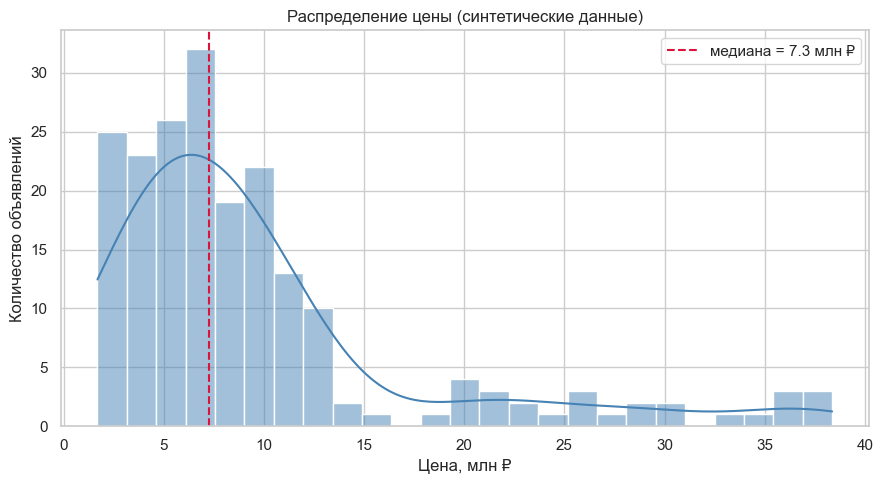

Skewness (асимметрия) price: 1.97


In [8]:
fig, ax = plt.subplots()
sns.histplot(eda_df["price"], bins=25, kde=True, ax=ax, color="steelblue")
ax.axvline(eda_df["price"].median(), color="crimson", linestyle="--", label=f"медиана = {eda_df['price'].median()/1e6:.1f} млн ₽")
ax.xaxis.set_major_formatter(RUB_M_FORMATTER)
ax.set_xlabel("Цена, млн ₽")
ax.set_ylabel("Количество объявлений")
ax.set_title("Распределение цены (синтетические данные)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Skewness (асимметрия) price: {eda_df['price'].skew():.2f}")

**Промежуточный вывод:** распределение цены смещено вправо (положительная
асимметрия) — типично для цен в целом. Это мотивирует логарифмирование
целевой переменной (`log1p(price)`) перед обучением моделей (раздел 15) —
проверим ниже, что log-преобразование действительно снижает асимметрию.

### 10.2 Распределение log(price)

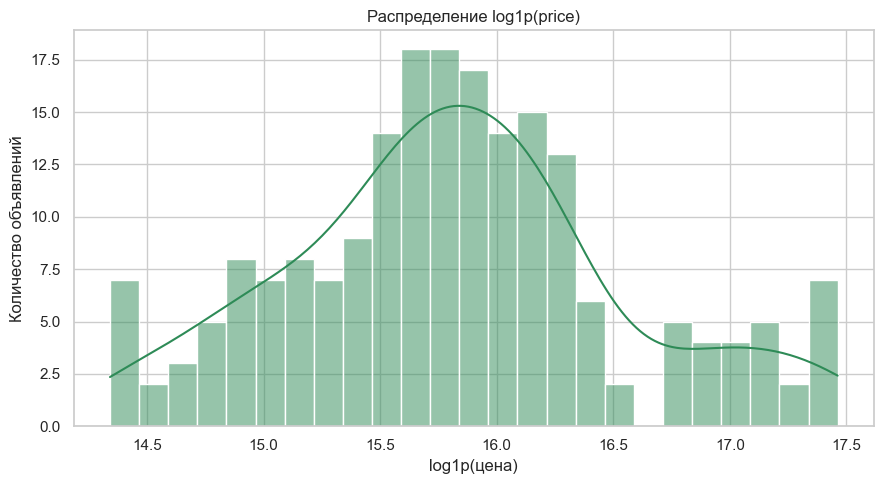

Skewness price:     1.97
Skewness log_price: 0.24


In [9]:
fig, ax = plt.subplots()
sns.histplot(eda_df["log_price"], bins=25, kde=True, ax=ax, color="seagreen")
ax.set_xlabel("log1p(цена)")
ax.set_ylabel("Количество объявлений")
ax.set_title("Распределение log1p(price)")
plt.tight_layout()
plt.show()

print(f"Skewness price:     {eda_df['price'].skew():.2f}")
print(f"Skewness log_price: {eda_df['log_price'].skew():.2f}")

**Промежуточный вывод:** асимметрия после логарифмирования заметно ближе к
нулю, чем у исходной цены. Это подтверждает решение обучать модели на
`log1p(price)` и конвертировать метрики обратно в рубли для отчётности
(разделы 15, 21) — так модели не будут излишне штрафоваться за
дорогие объекты в абсолютных рублях на этапе оптимизации.

### 10.3 Распределение площади (total_area, м²)

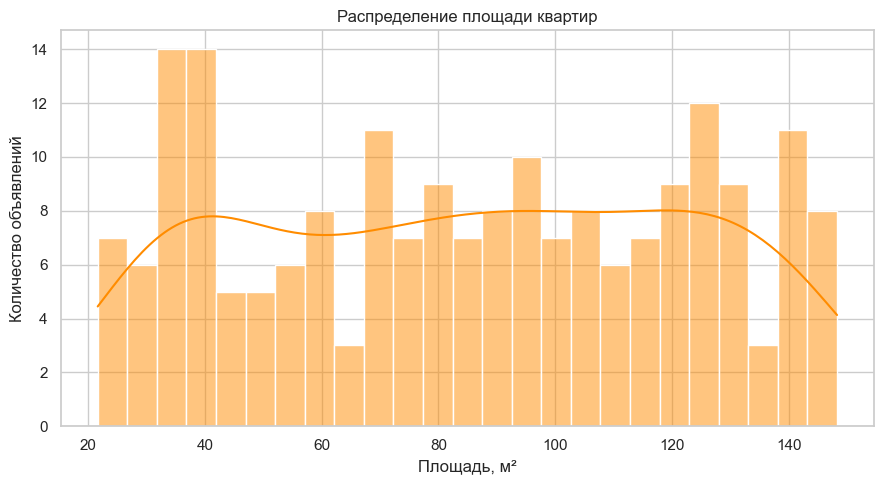

In [10]:
fig, ax = plt.subplots()
sns.histplot(eda_df["total_area"], bins=25, kde=True, ax=ax, color="darkorange")
ax.set_xlabel("Площадь, м²")
ax.set_ylabel("Количество объявлений")
ax.set_title("Распределение площади квартир")
plt.tight_layout()
plt.show()

**Промежуточный вывод:** площадь распределена достаточно широко (студии —
крупные квартиры) без явных выбросов за пределами `DataCleaner`-диапазона
[10, 500] м². Признак используется в модели как есть, плюс его
логарифм (`log_area`) и взаимодействие с числом комнат (`rooms_x_area`).

### 10.4 Количество объявлений по городам

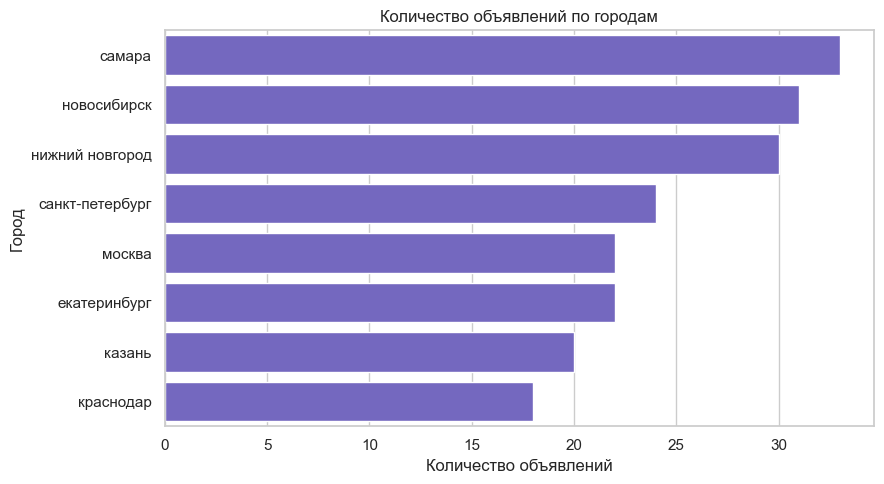

city
самара             33
новосибирск        31
нижний новгород    30
санкт-петербург    24
москва             22
екатеринбург       22
казань             20
краснодар          18
Name: count, dtype: int64


In [11]:
city_counts = eda_df["city"].value_counts().sort_values(ascending=False)
fig, ax = plt.subplots()
sns.barplot(x=city_counts.values, y=city_counts.index, ax=ax, color="slateblue")
ax.set_xlabel("Количество объявлений")
ax.set_ylabel("Город")
ax.set_title("Количество объявлений по городам")
plt.tight_layout()
plt.show()

print(city_counts)

**Промежуточный вывод:** города представлены неравномерно, но без экстремального
дисбаланса (от ~18 до ~33 строк на город). При таком объёме (200 строк на 8
городов) статистические тесты по городам (раздел 14) и per-city-baseline
(раздел 19) будут работать на очень малых подвыборках — это учтено в
интерпретации.

### 10.5 Цена за м² по городам

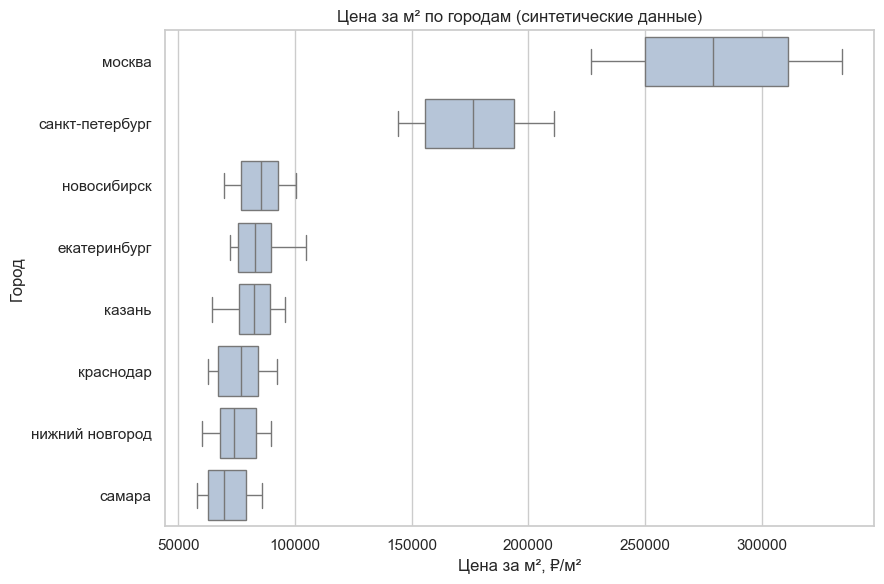

city
москва             279127.0
санкт-петербург    176136.0
новосибирск         85498.0
екатеринбург        82740.0
казань              82297.0
краснодар           76765.0
нижний новгород     73929.0
самара              69515.0
Name: price_per_sqm, dtype: float64


In [12]:
city_order = eda_df.groupby("city")["price_per_sqm"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(data=eda_df, x="price_per_sqm", y="city", order=city_order, ax=ax, color="lightsteelblue")
ax.set_xlabel("Цена за м², ₽/м²")
ax.set_ylabel("Город")
ax.set_title("Цена за м² по городам (синтетические данные)")
plt.tight_layout()
plt.show()

print(eda_df.groupby("city")["price_per_sqm"].median().sort_values(ascending=False).round(0))

**Промежуточный вывод:** цена за м² сильно различается по городам (Москва и
Санкт-Петербург заметно выше остальных) — это напрямую следует из констант
`base_price_per_sqm[город]`, зашитых в генератор. Различие явно проверяется
статистически в разделе 14 (гипотеза H1) и обосновывает включение города как
признака (one-hot) в модель, а не его исключение.

### 10.6 Цена vs площадь

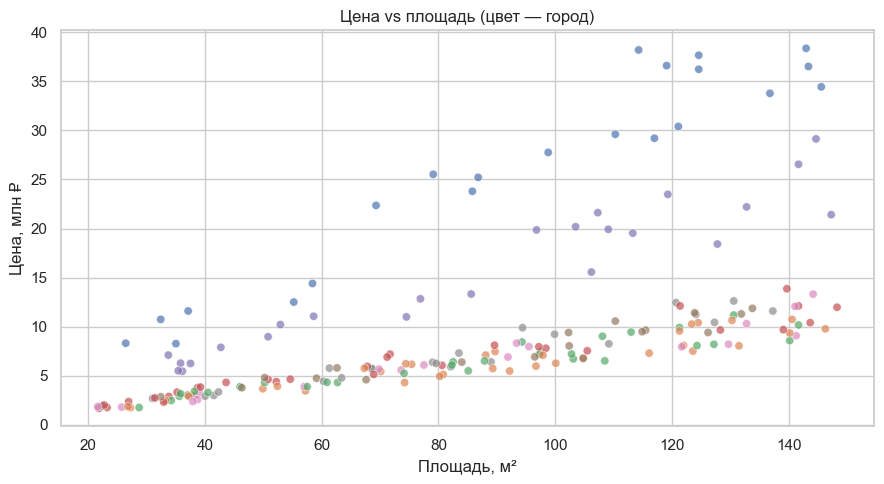

Pearson r  = 0.577 (p=4.14e-19)
Spearman r = 0.776 (p=1.44e-41)


In [13]:
fig, ax = plt.subplots()
sns.scatterplot(data=eda_df, x="total_area", y="price", hue="city", alpha=0.7, ax=ax, legend=False)
ax.yaxis.set_major_formatter(RUB_M_FORMATTER)
ax.set_xlabel("Площадь, м²")
ax.set_ylabel("Цена, млн ₽")
ax.set_title("Цена vs площадь (цвет — город)")
plt.tight_layout()
plt.show()

pearson_r, pearson_p = stats.pearsonr(eda_df["total_area"], eda_df["price"])
spearman_r, spearman_p = stats.spearmanr(eda_df["total_area"], eda_df["price"])
print(f"Pearson r  = {pearson_r:.3f} (p={pearson_p:.2e})")
print(f"Spearman r = {spearman_r:.3f} (p={spearman_p:.2e})")

**Промежуточный вывод:** между площадью и ценой — сильная монотонная связь
(проверяется формально в разделе 14, гипотеза H4). Площадь — самый сильный
одиночный предиктор в данных, что оправдывает и прямое включение
`total_area`, и производные признаки (`log_area`, `rooms_x_area`) в
финальный набор признаков модели.

### 10.7 Цена по количеству комнат

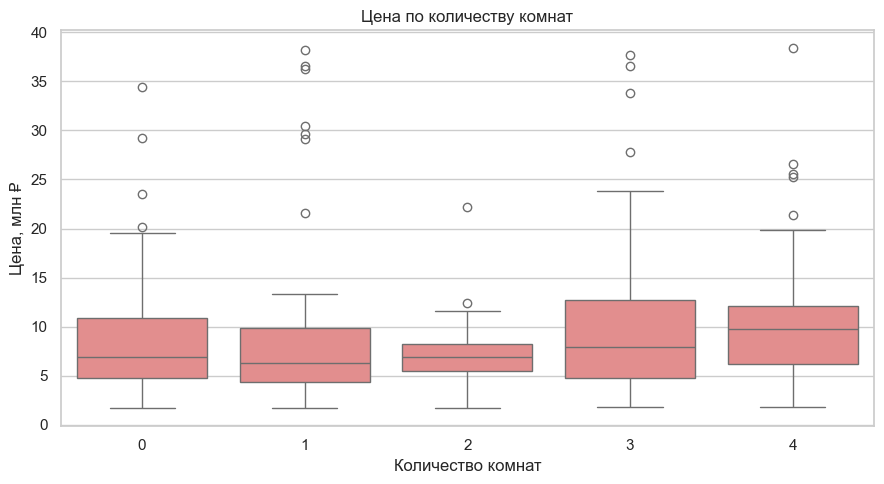

In [14]:
fig, ax = plt.subplots()
sns.boxplot(data=eda_df, x="rooms", y="price", ax=ax, color="lightcoral")
ax.yaxis.set_major_formatter(RUB_M_FORMATTER)
ax.set_xlabel("Количество комнат")
ax.set_ylabel("Цена, млн ₽")
ax.set_title("Цена по количеству комнат")
plt.tight_layout()
plt.show()

**Промежуточный вывод:** цена растёт с числом комнат, что ожидаемо
коррелирует с площадью (комнаты и площадь не независимы). Это мотивирует
явное взаимодействие `rooms_x_area` как отдельный признак, вместо того чтобы
полагаться на модель для автоматического обнаружения этого произведения
(особенно важно для линейных baseline-моделей, раздел 19).

### 10.8 Цена по типу дома (building_type)

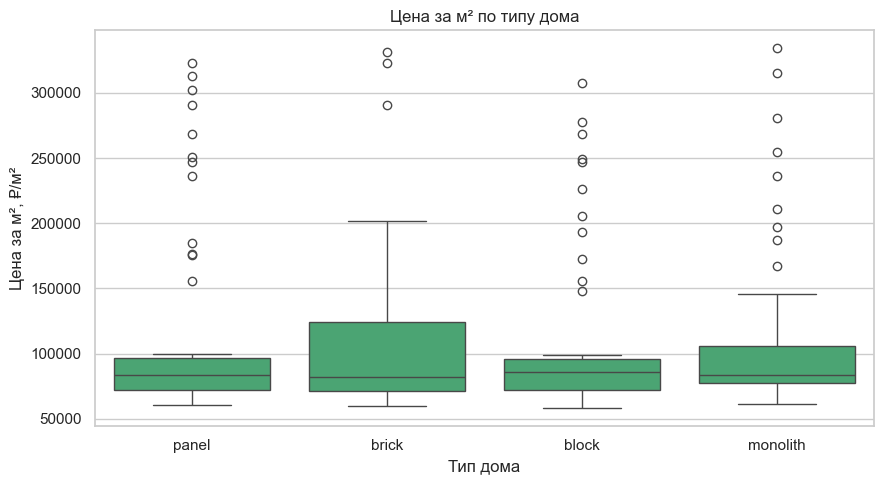

building_type
block       85537.0
brick       81681.0
monolith    83428.0
panel       83225.0
Name: price_per_sqm, dtype: float64


In [15]:
fig, ax = plt.subplots()
sns.boxplot(data=eda_df, x="building_type", y="price_per_sqm", ax=ax, color="mediumseagreen")
ax.set_xlabel("Тип дома")
ax.set_ylabel("Цена за м², ₽/м²")
ax.set_title("Цена за м² по типу дома")
plt.tight_layout()
plt.show()

print(eda_df.groupby("building_type")["price_per_sqm"].median().round(0))

**Промежуточный вывод:** визуально различия между типами домов невелики —
формально проверяется в разделе 14 (гипотеза H6). Забегая вперёд: тест
Краскела-Уоллиса не находит значимых различий. Признак `building_type` тем
не менее оставлен в модели (one-hot), так как это осмысленный
бизнес-признак: раньше он вообще не доходил до модели, хотя принимался на
входе API/UI — отсутствие сигнала на 200 синтетических строках не является
доказательством его нерелевантности на реальных данных.

### 10.9 Эффект первого / последнего этажа

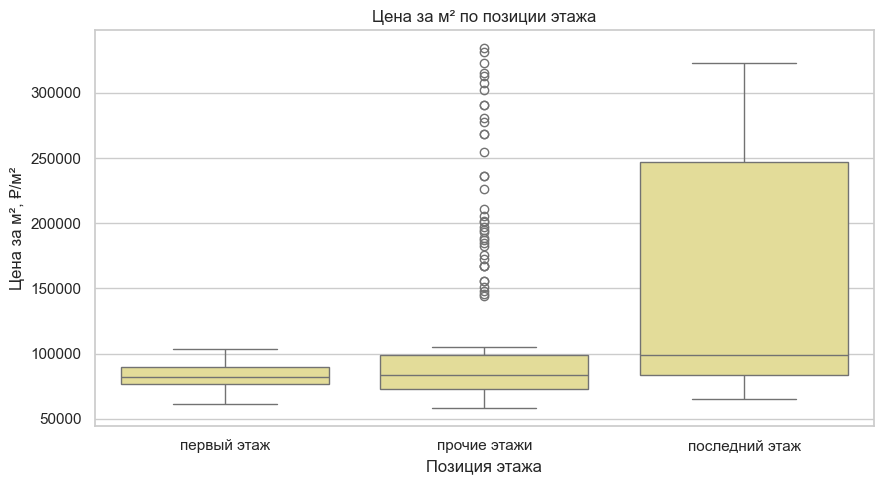

                count     median
floor_position                  
первый этаж        14  81668.115
последний этаж     15  99243.120
прочие этажи      171  83411.080


In [16]:
floor_effect = eda_df.copy()
floor_effect["floor_position"] = np.select(
    [floor_effect["is_first_floor"] == 1, floor_effect["is_top_floor"] == 1],
    ["первый этаж", "последний этаж"],
    default="прочие этажи",
)

fig, ax = plt.subplots()
order = ["первый этаж", "прочие этажи", "последний этаж"]
sns.boxplot(data=floor_effect, x="floor_position", y="price_per_sqm", order=order, ax=ax, color="khaki")
ax.set_xlabel("Позиция этажа")
ax.set_ylabel("Цена за м², ₽/м²")
ax.set_title("Цена за м² по позиции этажа")
plt.tight_layout()
plt.show()

print(floor_effect.groupby("floor_position")["price_per_sqm"].agg(["count", "median"]))

**Промежуточный вывод:** «последний этаж» визуально выглядит немного дороже
за м², «первый этаж» — почти не отличается от прочих. Оба эффекта проверены
формально в разделе 14 (гипотезы H2, H3) — забегая вперёд: эффект первого
этажа статистически не значим, а эффект последнего этажа значим до поправки
на множественные сравнения, но **не значим после неё** — то есть это,
вероятно, шум малой выборки, а не устойчивая закономерность генератора.

### 10.10 Корреляционная матрица Спирмена (числовые признаки)

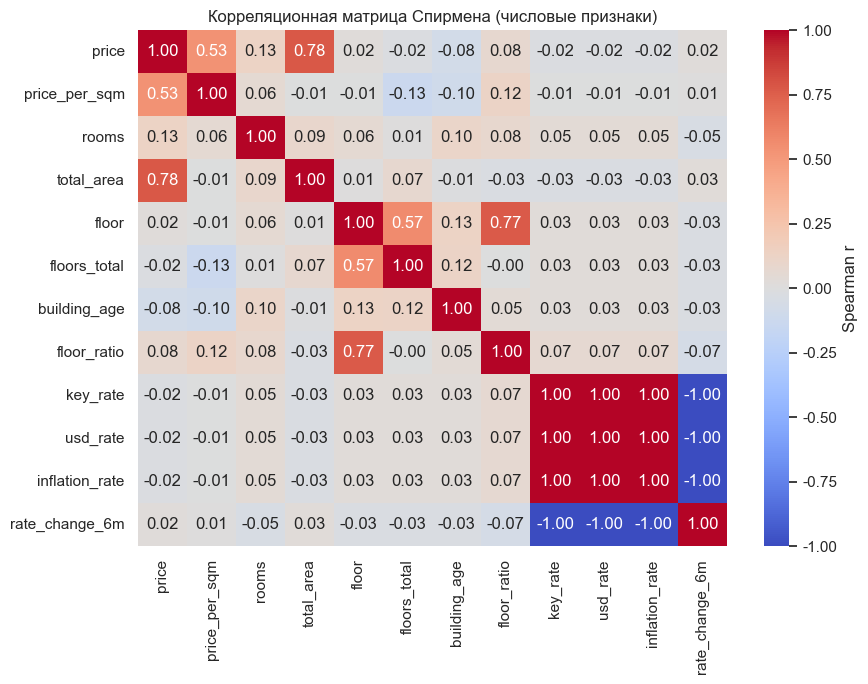

In [17]:
numeric_cols_for_corr = [
    "price", "price_per_sqm", "rooms", "total_area", "floor", "floors_total",
    "building_age", "floor_ratio", "key_rate", "usd_rate", "inflation_rate",
    "rate_change_6m",
]
corr_matrix = eda_df[numeric_cols_for_corr].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, cbar_kws={"label": "Spearman r"})
ax.set_title("Корреляционная матрица Спирмена (числовые признаки)")
plt.tight_layout()
plt.show()

**Промежуточный вывод:** `total_area` — самый сильно коррелированный с ценой
числовой признак (см. также раздел 10.6). Макроэкономические признаки
(`key_rate`, `usd_rate`, `inflation_rate`, `rate_change_6m`) слабо
коррелируют с ценой на этом датасете — правдоподобно, так как в генераторе
цена определяется в первую очередь городом и площадью, а макропоказатели
добавлены как контекстные признаки, а не как основной драйвер цены. Это
эмпирическое наблюдение будет полезно сверить с результатами permutation
importance в разделе 24.

## 11. Проверка статистических гипотез

Проверяем 6 гипотез, естественно вытекающих из EDA (раздел 10). Для каждой:
формулируем H0/H1, проверяем предпосылки (нормальность через тест
Шапиро-Уилка) и выбираем параметрический или непараметрический тест,
считаем размер эффекта, а затем **корректируем p-value на 6 сравнений**
методом Бенджамини-Хохберга (контроль FDR), так как множественное
тестирование без поправки завышает вероятность ложных открытий.

> Все выводы ниже описывают закономерности **синтетического генератора**, а
> не поведение реального рынка недвижимости.

In [18]:
shapiro_price_per_sqm = stats.shapiro(eda_df["price_per_sqm"])
shapiro_price = stats.shapiro(eda_df["price"])
print(f"Shapiro-Wilk price_per_sqm: W={shapiro_price_per_sqm.statistic:.3f}, p={shapiro_price_per_sqm.pvalue:.2e}")
print(f"Shapiro-Wilk price:         W={shapiro_price.statistic:.3f}, p={shapiro_price.pvalue:.2e}")
print()
print("Обе переменные значимо отклоняются от нормальности (p << 0.05)."
      " Используем непараметрические тесты (Манн-Уитни, Краскела-Уоллиса,"
      " корреляция Спирмена) вместо t-теста/ANOVA/Пирсона по умолчанию.")

Shapiro-Wilk price_per_sqm: W=0.683, p=3.68e-19
Shapiro-Wilk price:         W=0.759, p=8.25e-17

Обе переменные значимо отклоняются от нормальности (p << 0.05). Используем непараметрические тесты (Манн-Уитни, Краскела-Уоллиса, корреляция Спирмена) вместо t-теста/ANOVA/Пирсона по умолчанию.


### H1 — цена за м² отличается между городами

In [19]:
groups_city = [g["price_per_sqm"].values for _, g in eda_df.groupby("city")]
h1_stat, h1_p = stats.kruskal(*groups_city)
n_h1 = len(eda_df)
k_groups = len(groups_city)
# eta-squared для Kruskal-Wallis (эффект-сайз): (H - k + 1) / (n - k)
h1_eta_sq = (h1_stat - k_groups + 1) / (n_h1 - k_groups)

print(f"H1: Kruskal-Wallis, n={n_h1}, k={k_groups} городов")
print(f"H-statistic = {h1_stat:.2f}, p = {h1_p:.2e}, eta^2 = {h1_eta_sq:.3f}")

H1: Kruskal-Wallis, n=200, k=8 городов
H-statistic = 129.50, p = 7.98e-25, eta^2 = 0.638


- **H0:** медиана `price_per_sqm` одинакова для всех 8 городов.
- **H1:** хотя бы один город отличается по медиане `price_per_sqm`.
- **Тест:** Краскела-Уоллиса (не ANOVA — `price_per_sqm` не нормально
  распределена по группам, см. Shapiro выше).
- **Практический вывод:** различия между городами статистически значимы и
  крупные по величине эффекта (η² ≈ 0.63, что является очень большим
  эффектом). Это напрямую следует из констант `base_price_per_sqm[город]` в
  генераторе — обосновывает **обязательное** включение города (one-hot) в
  модель.

**Пост-хок: Москва vs каждый другой город (Манн-Уитни, поправка Холма)**

In [20]:
moscow_ppsqm = eda_df.loc[eda_df["city"] == "москва", "price_per_sqm"].values
other_cities = [c for c in eda_df["city"].unique() if c != "москва"]

posthoc_pvals, posthoc_labels = [], []
for c in other_cities:
    other_vals = eda_df.loc[eda_df["city"] == c, "price_per_sqm"].values
    u_stat, u_p = stats.mannwhitneyu(moscow_ppsqm, other_vals, alternative="two-sided")
    posthoc_pvals.append(u_p)
    posthoc_labels.append(f"москва vs {c}")

_, posthoc_p_adj, _, _ = multipletests(posthoc_pvals, alpha=ALPHA, method="holm")
posthoc_df = pd.DataFrame({
    "сравнение": posthoc_labels,
    "p_raw": posthoc_pvals,
    "p_holm": posthoc_p_adj,
    "значимо (adj<0.05)": posthoc_p_adj < ALPHA,
})
print(posthoc_df.to_string(index=False))

                сравнение        p_raw       p_holm  значимо (adj<0.05)
         москва vs самара 4.729588e-10 3.310712e-09                True
москва vs нижний новгород 1.041621e-09 5.208103e-09                True
    москва vs новосибирск 7.927644e-10 4.756586e-09                True
москва vs санкт-петербург 6.858287e-09 2.743315e-08                True
         москва vs казань 3.239832e-08 6.479664e-08                True
      москва vs краснодар 7.903996e-08 7.903996e-08                True
   москва vs екатеринбург 1.439361e-08 4.318082e-08                True


### H2 — цена за м² на первом этаже отличается от прочих этажей

In [21]:
first_floor_ppsqm = eda_df.loc[eda_df["is_first_floor"] == 1, "price_per_sqm"]
rest_ppsqm_1 = eda_df.loc[eda_df["is_first_floor"] == 0, "price_per_sqm"]
n1a, n1b = len(first_floor_ppsqm), len(rest_ppsqm_1)

h2_stat, h2_p = stats.mannwhitneyu(first_floor_ppsqm, rest_ppsqm_1, alternative="two-sided")
# rank-biserial correlation как эффект-сайз для Манна-Уитни
h2_rank_biserial = 1 - (2 * h2_stat) / (n1a * n1b)

print(f"H2: Mann-Whitney U, n_first={n1a}, n_rest={n1b}")
print(f"U = {h2_stat:.1f}, p = {h2_p:.3f}, rank-biserial r = {h2_rank_biserial:.3f}")
print(f"Медиана (первый этаж) = {first_floor_ppsqm.median():.0f} RUB/m2")
print(f"Медиана (прочие)      = {rest_ppsqm_1.median():.0f} RUB/m2")

H2: Mann-Whitney U, n_first=14, n_rest=186
U = 1153.0, p = 0.477, rank-biserial r = 0.114
Медиана (первый этаж) = 81668 RUB/m2
Медиана (прочие)      = 83528 RUB/m2


- **H0:** распределение `price_per_sqm` одинаково для первого этажа и прочих.
- **H1:** распределения отличаются.
- **Тест:** Манн-Уитни (непараметрический, малая и неравная по размеру
  подвыборка первого этажа — 14 против 186 строк).
- **Практический вывод:** различие статистически не значимо и эффект близок
  к нулю. В этом синтетическом генераторе «первый этаж» не выступает
  самостоятельным ценовым фактором.

### H3 — цена за м² на последнем этаже отличается от прочих этажей

In [22]:
top_floor_ppsqm = eda_df.loc[eda_df["is_top_floor"] == 1, "price_per_sqm"]
rest_ppsqm_2 = eda_df.loc[eda_df["is_top_floor"] == 0, "price_per_sqm"]
n2a, n2b = len(top_floor_ppsqm), len(rest_ppsqm_2)

h3_stat, h3_p = stats.mannwhitneyu(top_floor_ppsqm, rest_ppsqm_2, alternative="two-sided")
h3_rank_biserial = 1 - (2 * h3_stat) / (n2a * n2b)

print(f"H3: Mann-Whitney U, n_top={n2a}, n_rest={n2b}")
print(f"U = {h3_stat:.1f}, p = {h3_p:.3f} (до поправки), rank-biserial r = {h3_rank_biserial:.3f}")
print(f"Медиана (последний этаж) = {top_floor_ppsqm.median():.0f} RUB/m2")
print(f"Медиана (прочие)         = {rest_ppsqm_2.median():.0f} RUB/m2")

H3: Mann-Whitney U, n_top=15, n_rest=185
U = 1827.0, p = 0.042 (до поправки), rank-biserial r = -0.317
Медиана (последний этаж) = 99243 RUB/m2
Медиана (прочие)         = 82594 RUB/m2


- **H0:** распределение `price_per_sqm` одинаково для последнего этажа и прочих.
- **H1:** распределения отличаются.
- **Тест:** Манн-Уитни.
- **Практический вывод:** *до* поправки на множественные сравнения p≈0.042
  (номинально значимо), но при 200 строках и всего 15 объектов на последнем
  этаже стоит быть осторожными — см. итоговую таблицу с поправкой ниже,
  где именно этот результат перестаёт быть значимым.

### H4 — площадь коррелирует с ценой

In [23]:
h4_stat, h4_p = stats.spearmanr(eda_df["total_area"], eda_df["price"])
n_h4 = len(eda_df)

print(f"H4: Spearman correlation, n={n_h4}")
print(f"rho = {h4_stat:.3f}, p = {h4_p:.2e}")

H4: Spearman correlation, n=200
rho = 0.776, p = 1.44e-41


- **H0:** ρ(total_area, price) = 0.
- **H1:** ρ(total_area, price) ≠ 0.
- **Тест:** корреляция Спирмена (монотонная связь, обе переменные не
  нормальны).
- **Практический вывод:** очень сильная (ρ≈0.78) и высокозначимая
  положительная связь — площадь является главным одиночным предиктором
  цены в этом наборе данных, что напрямую отражено в дизайне признаков
  (раздел 15: `total_area`, `log_area`, `rooms_x_area`).

### H5 — возраст здания коррелирует с ценой за м²

In [24]:
h5_stat, h5_p = stats.spearmanr(eda_df["building_age"], eda_df["price_per_sqm"])
n_h5 = len(eda_df)

print(f"H5: Spearman correlation, n={n_h5}")
print(f"rho = {h5_stat:.3f}, p = {h5_p:.3f}")

H5: Spearman correlation, n=200
rho = -0.098, p = 0.168


- **H0:** ρ(building_age, price_per_sqm) = 0.
- **H1:** ρ(building_age, price_per_sqm) ≠ 0.
- **Тест:** корреляция Спирмена.
- **Практический вывод:** связь слабая и статистически не значима. В
  генераторе возраст здания, по-видимому, не является явным множителем
  цены за м² — признак `building_age` остаётся в модели как потенциально
  полезный для нелинейных взаимодействий (деревья/бустинг), но не как
  сильный одиночный сигнал.

### H6 — цена за м² отличается между типами домов

In [25]:
groups_bt = [g["price_per_sqm"].values for _, g in eda_df.groupby("building_type")]
h6_stat, h6_p = stats.kruskal(*groups_bt)
n_h6 = len(eda_df)
k_bt = len(groups_bt)
h6_eta_sq = (h6_stat - k_bt + 1) / (n_h6 - k_bt)

print(f"H6: Kruskal-Wallis, n={n_h6}, k={k_bt} типов домов")
print(f"H-statistic = {h6_stat:.3f}, p = {h6_p:.3f}, eta^2 = {h6_eta_sq:.4f}")

H6: Kruskal-Wallis, n=200, k=4 типов домов
H-statistic = 0.947, p = 0.814, eta^2 = -0.0105


- **H0:** медиана `price_per_sqm` одинакова для всех типов домов.
- **H1:** хотя бы один тип дома отличается.
- **Тест:** Краскела-Уоллиса.
- **Практический вывод:** различий не обнаружено (эффект практически
  нулевой). `building_type` остаётся в модели по бизнес-соображениям (см.
  раздел 10.8), но на этом синтетическом датасете он не несёт сильного
  самостоятельного сигнала для цены за м².

### Итоговая таблица с поправкой на множественные сравнения (Бенджамини-Хохберг)

In [26]:
hypotheses_summary = pd.DataFrame([
    {
        "hypothesis": "H1: price_per_sqm differs by city",
        "test": "Kruskal-Wallis",
        "n": n_h1,
        "statistic": h1_stat,
        "p_value": h1_p,
        "alpha": ALPHA,
        "effect_size": h1_eta_sq,
        "effect_size_type": "eta_squared",
    },
    {
        "hypothesis": "H2: price_per_sqm differs on 1st floor vs rest",
        "test": "Mann-Whitney U",
        "n": n1a + n1b,
        "statistic": h2_stat,
        "p_value": h2_p,
        "alpha": ALPHA,
        "effect_size": h2_rank_biserial,
        "effect_size_type": "rank_biserial_r",
    },
    {
        "hypothesis": "H3: price_per_sqm differs on top floor vs rest",
        "test": "Mann-Whitney U",
        "n": n2a + n2b,
        "statistic": h3_stat,
        "p_value": h3_p,
        "alpha": ALPHA,
        "effect_size": h3_rank_biserial,
        "effect_size_type": "rank_biserial_r",
    },
    {
        "hypothesis": "H4: total_area correlates with price",
        "test": "Spearman correlation",
        "n": n_h4,
        "statistic": h4_stat,
        "p_value": h4_p,
        "alpha": ALPHA,
        "effect_size": h4_stat,
        "effect_size_type": "spearman_rho",
    },
    {
        "hypothesis": "H5: building_age correlates with price_per_sqm",
        "test": "Spearman correlation",
        "n": n_h5,
        "statistic": h5_stat,
        "p_value": h5_p,
        "alpha": ALPHA,
        "effect_size": h5_stat,
        "effect_size_type": "spearman_rho",
    },
    {
        "hypothesis": "H6: price_per_sqm differs by building_type",
        "test": "Kruskal-Wallis",
        "n": n_h6,
        "statistic": h6_stat,
        "p_value": h6_p,
        "alpha": ALPHA,
        "effect_size": h6_eta_sq,
        "effect_size_type": "eta_squared",
    },
])

reject, p_adj, _, _ = multipletests(hypotheses_summary["p_value"], alpha=ALPHA, method="fdr_bh")
hypotheses_summary["p_value_adj_bh"] = p_adj
hypotheses_summary["significant_after_correction"] = reject

conclusions = {
    "H1: price_per_sqm differs by city": "Значимо: город — обязательный признак модели.",
    "H2: price_per_sqm differs on 1st floor vs rest": "Не значимо: эффект первого этажа не подтверждён.",
    "H3: price_per_sqm differs on top floor vs rest": "Значимо ДО поправки, НЕ значимо после FDR — вероятно шум малой выборки.",
    "H4: total_area correlates with price": "Значимо, сильный эффект: площадь — главный числовой предиктор.",
    "H5: building_age correlates with price_per_sqm": "Не значимо: возраст здания не даёт самостоятельного сигнала по цене/м².",
    "H6: price_per_sqm differs by building_type": "Не значимо: тип дома оставлен по бизнес-логике, не по силе сигнала.",
}
hypotheses_summary["conclusion"] = hypotheses_summary["hypothesis"].map(conclusions)

display_cols = ["hypothesis", "test", "n", "statistic", "p_value", "p_value_adj_bh", "significant_after_correction", "effect_size", "conclusion"]
print(hypotheses_summary[display_cols].round(4).to_string(index=False))

                                    hypothesis                 test   n  statistic  p_value  p_value_adj_bh  significant_after_correction  effect_size                                                              conclusion
             H1: price_per_sqm differs by city       Kruskal-Wallis 200   129.5043   0.0000          0.0000                          True       0.6380                           Значимо: город — обязательный признак модели.
H2: price_per_sqm differs on 1st floor vs rest       Mann-Whitney U 200  1153.0000   0.4771          0.5725                         False       0.1144                        Не значимо: эффект первого этажа не подтверждён.
H3: price_per_sqm differs on top floor vs rest       Mann-Whitney U 200  1827.0000   0.0417          0.0835                         False      -0.3168 Значимо ДО поправки, НЕ значимо после FDR — вероятно шум малой выборки.
          H4: total_area correlates with price Spearman correlation 200     0.7764   0.0000          0.0000 

**Промежуточный вывод:** после поправки Бенджамини-Хохберга на 6 сравнений
статистически устойчивы только **H1 (город)** и **H4 (площадь)** — оба
имеют большие эффекты. H3 (последний этаж) — хороший пример, почему нужна
поправка на множественные сравнения: без неё результат выглядел бы значимым
(p≈0.042), но не выдерживает контроля FDR. Это напрямую формирует итоговый
список важных признаков модели: город и площадь — приоритет; этажность,
тип дома, возраст здания — оставлены в модели как разумные бизнес-признаки,
но не как статистически подтверждённые на этой синтетической выборке
драйверы цены.

In [27]:
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

stats_csv_cols = ["hypothesis", "test", "n", "statistic", "p_value", "alpha", "effect_size", "conclusion"]
hypotheses_summary[stats_csv_cols].to_csv(REPORTS_DIR / "statistical_tests.csv", index=False)
print(f"Сохранено: {(REPORTS_DIR / 'statistical_tests.csv').relative_to(PROJECT_ROOT)}")

Сохранено: reports\statistical_tests.csv


In [28]:
_stat_report_lines = [
    "# Статистический анализ синтетического датасета",
    "",
    "Источник данных: `data/processed/real_estate_engineered.synthetic.csv`"
    " (200 синтетических строк — см. `DATA_CARD.md`).",
    "Все выводы ниже описывают поведение генератора синтетических данных, а"
    " НЕ реальный рынок недвижимости.",
    "",
    f"Уровень значимости alpha = {ALPHA}. Поправка на множественные сравнения:"
    " Бенджамини-Хохберг (FDR) по 6 гипотезам.",
    "",
    "## Проверка предпосылок",
    "",
    f"- Shapiro-Wilk (price): W={shapiro_price.statistic:.3f}, p={shapiro_price.pvalue:.2e}"
    " -> нормальность отвергнута.",
    f"- Shapiro-Wilk (price_per_sqm): W={shapiro_price_per_sqm.statistic:.3f},"
    f" p={shapiro_price_per_sqm.pvalue:.2e} -> нормальность отвергнута.",
    "- Следствие: везде используются непараметрические тесты"
    " (Mann-Whitney U, Kruskal-Wallis, Spearman) вместо t-теста/ANOVA/Пирсона.",
    "",
    "## Результаты по гипотезам",
    "",
]

for _, row in hypotheses_summary.iterrows():
    _stat_report_lines.append(f"### {row['hypothesis']}")
    _stat_report_lines.append("")
    _stat_report_lines.append(f"- Тест: {row['test']}")
    _stat_report_lines.append(f"- n = {int(row['n'])}")
    _stat_report_lines.append(f"- Статистика = {row['statistic']:.4f}")
    _stat_report_lines.append(f"- p-value (сырой) = {row['p_value']:.3e}")
    _stat_report_lines.append(f"- p-value (BH-скорректированный) = {row['p_value_adj_bh']:.3e}")
    _stat_report_lines.append(f"- Значимо после поправки: {bool(row['significant_after_correction'])}")
    _stat_report_lines.append(f"- Размер эффекта ({row['effect_size_type']}) = {row['effect_size']:.4f}")
    _stat_report_lines.append(f"- Практический вывод: {row['conclusion']}")
    _stat_report_lines.append("")

_stat_report_lines += [
    "## Пост-хок сравнение (H1): Москва vs каждый другой город",
    "",
    "Манн-Уитни с поправкой Холма (Holm), т.к. это вложенная серия сравнений"
    " внутри уже значимого общего теста Kruskal-Wallis.",
    "",
    "```",
    posthoc_df.to_string(index=False),
    "```",
    "",
    "## Общий вывод",
    "",
    "Из 6 проверенных гипотез статистически устойчивы (после поправки на"
    " множественные сравнения) только различие цены за м² между городами (H1)"
    " и связь площади с ценой (H4) — оба ожидаемо отражают формулу генератора"
    " `price ~= base_price_per_sqm[city] * total_area * noise`. Остальные"
    " гипотезы (этаж, возраст здания, тип дома) не показали устойчивого"
    " сигнала на этой синтетической выборке из 200 строк.",
]

_stat_report_text = "\n".join(_stat_report_lines)
(REPORTS_DIR / "STATISTICAL_ANALYSIS.md").write_text(_stat_report_text, encoding="utf-8")
print(f"Сохранено: {(REPORTS_DIR / 'STATISTICAL_ANALYSIS.md').relative_to(PROJECT_ROOT)}")

Сохранено: reports\STATISTICAL_ANALYSIS.md


## 12. Построение признаков (Feature Engineering)

Переиспользуем `FeatureEngineer.prepare_for_training()` — тот же
production-код, что использует `scripts/run_model_training_real.py`.
Итоговый набор — 27 признаков: 11 числовых (`rooms`, `total_area`, `floor`,
`floors_total`, `building_age`, `floor_ratio`, `is_top_floor`,
`is_first_floor`, `log_area`, `room_density`, `rooms_x_area`), 8
one-hot-колонок города и 4 one-hot-колонки типа дома (все — по
фиксированному, а не «выученному» словарю категорий), плюс 4
макроэкономических признака (`key_rate`, `usd_rate`, `inflation_rate`,
`rate_change_6m`). Целевая переменная — `log1p(price)`.

**Почему one-hot по фиксированным категориям, а не `LabelEncoder`?**
Предыдущая версия пайплайна кодировала город через `LabelEncoder.fit()` на
всём датафрейме **до** разбиения на train/test — технически это не
приводило к утечке целевой переменной, но кодирование было
fit-before-split, а `building_type` вообще принимался на входе API/UI, но
игнорировался моделью. Текущая схема (`CITY_SLUGS`/`BUILDING_TYPE_SLUGS` —
захардкоженные константы) устраняет обе проблемы разом: кодирование ничего
не «фитит» на данных (fold-safe по построению), а `building_type` теперь
реально доходит до модели.

`price_per_sqm` **намеренно исключён** из признаков модели — это отношение
цены к площади, то есть прямая производная целевой переменной (data
leakage guard). Он остаётся в датафрейме только для EDA/статистики выше.

In [29]:
X, y = fe.prepare_for_training(listings_clean)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape} (log1p(price))")
print()
print("Список признаков:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")

2026-07-29 15:52:10 | INFO     | src.features.feature_engineering | Feature creation done. DataFrame shape: (200, 38)


2026-07-29 15:52:10 | INFO     | src.features.feature_engineering | prepare_for_training: X=(200, 27), y shape=(200,), features=['rooms', 'total_area', 'floor', 'floors_total', 'building_age', 'floor_ratio', 'is_top_floor', 'is_first_floor', 'log_area', 'room_density', 'rooms_x_area', 'city_moskva', 'city_spb', 'city_ekaterinburg', 'city_novosibirsk', 'city_kazan', 'city_nizhniy_novgorod', 'city_samara', 'city_krasnodar', 'building_type_panel', 'building_type_brick', 'building_type_monolith', 'building_type_block', 'key_rate', 'usd_rate', 'inflation_rate', 'rate_change_6m']


X shape: (200, 27)
y shape: (200,) (log1p(price))

Список признаков:
   1. rooms
   2. total_area
   3. floor
   4. floors_total
   5. building_age
   6. floor_ratio
   7. is_top_floor
   8. is_first_floor
   9. log_area
  10. room_density
  11. rooms_x_area
  12. city_moskva
  13. city_spb
  14. city_ekaterinburg
  15. city_novosibirsk
  16. city_kazan
  17. city_nizhniy_novgorod
  18. city_samara
  19. city_krasnodar
  20. building_type_panel
  21. building_type_brick
  22. building_type_monolith
  23. building_type_block
  24. key_rate
  25. usd_rate
  26. inflation_rate
  27. rate_change_6m


**Промежуточный вывод:** получено 27 признаков без пропусков (проверяется
явно в разделе 13 — leakage check). Это тот же самый список и порядок
признаков, что хранится в `feature_names` уже обученного артефакта модели
(сверим в разделе 20).

## 13. Проверка отсутствия утечек данных (leakage check)

Явно, а не декларативно, проверяем три источника потенциальной утечки:

1. `price_per_sqm` и `log_price` не должны присутствовать в `X`.
2. One-hot кодирование города/типа дома не должно ничего «фитить» на данных
   (это гарантировано конструкцией `one_hot_fixed_categories()` — категории
   заданы константами `CITY_SLUGS`/`BUILDING_TYPE_SLUGS`, а не выучены).
3. В данных нет дублирующихся `url` — то есть один и тот же объект не может
   случайно попасть и в train, и в test после разбиения (group leakage).

In [30]:
leaked_cols = [c for c in ("price_per_sqm", "log_price", "price") if c in X.columns]
assert not leaked_cols, f"Обнаружена утечка целевой переменной в признаках: {leaked_cols}"
print("OK: price_per_sqm / log_price / price отсутствуют в X.")

expected_onehot = set(CITY_ONEHOT_COLUMNS) | set(BUILDING_TYPE_ONEHOT_COLUMNS)
assert expected_onehot.issubset(set(X.columns)), "Ожидаемые one-hot колонки отсутствуют в X."
print(f"OK: {len(expected_onehot)} one-hot колонок города/типа дома на месте"
      " (кодирование по фиксированному словарю, ничего не 'fit' на данных).")

n_dup_urls = listings_clean["url"].duplicated().sum() if "url" in listings_clean.columns else raw_df["url"].duplicated().sum()
assert n_dup_urls == 0, f"Обнаружены дублирующиеся url: {n_dup_urls} — риск group leakage при сплите."
print("OK: дублирующихся url нет — риск group leakage через повторные объявления отсутствует.")

assert X.isna().sum().sum() == 0, "В X есть пропуски."
print("OK: пропусков в X нет.")

OK: price_per_sqm / log_price / price отсутствуют в X.
OK: 12 one-hot колонок города/типа дома на месте (кодирование по фиксированному словарю, ничего не 'fit' на данных).
OK: дублирующихся url нет — риск group leakage через повторные объявления отсутствует.
OK: пропусков в X нет.


**Промежуточный вывод:** утечек не обнаружено. Все три проверки — явные
`assert`, а не текстовые заявления, поэтому при будущих изменениях
пайплайна (например, переходе на реальные данные) эта ячейка сразу
провалится, если что-то сломается.

## 14. Разбиение на train/test

Используем случайное 80/20 разбиение с `random_state=42` — точно так же,
как `ModelTrainer.train()`/production-скрипт `run_model_training_real.py`
(это позволяет напрямую сверять метрики ноутбука с сохранённым артефактом
модели, раздел 20).

**Почему не временной (temporal) сплит?** В синтетическом генераторе
`date_published` присваивается случайно (`rng`-выбор даты), а не отражает
органический порядок появления объявлений во времени — то есть
временной сплит здесь создал бы ложное ощущение методологической строгости,
не отражая никакой реальной хронологии. Для реальных скрапленных данных
временной сплит был бы осмысленным и рекомендуется в дорожной карте
(раздел 29).

**Group leakage:** уже проверено в разделе 13 — дубликатов `url` нет,
поэтому случайное разбиение не рискует поместить один и тот же объект и в
train, и в test.

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]} строк, Test (holdout): {X_test.shape[0]} строк")
print(f"Доля holdout: {len(X_test) / len(X):.0%}")

# KFold для CV-протокола (раздел 15-16), тоже фиксированный random_state,
# применяется ТОЛЬКО к train-части, чтобы holdout оставался полностью
# невидимым до финальной оценки.
cv_splitter = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

Train: 160 строк, Test (holdout): 40 строк
Доля holdout: 20%


**Промежуточный вывод:** 160 строк train / 40 строк test — тот же размер
holdout (40), что зафиксирован в метаданных сохранённого артефакта модели
(`n_holdout: 40` в `prediction_interval`, раздел 20). Все baseline- и
«настоящие» модели в разделах 15-17 будут оцениваться на этом же train/test
разбиении и на одном и том же `KFold(cv_splitter)` для перекрёстной
проверки — единый протокол сравнения, как того требует раздел 21.

## 15. Базовые решения (baselines)

Baseline-модели дают точку отсчёта: если сложная модель не превосходит
простое правило «медиана по городу», её сложность не оправдана. Реализуем
5 baseline-решений:

1. **Глобальная медиана цены** — константа для всех объектов.
2. **Медиана цены по городу** — использует единственный категориальный
   признак с наибольшим статистическим эффектом (H1, раздел 11).
3. **Медиана цены за м² по городу × площадь объекта** — чуть более
   информативный baseline, учитывающий и город, и площадь (два признака с
   доказанным эффектом).
4. **`sklearn.dummy.DummyRegressor`** (стратегия `mean`) — стандартный
   sklearn-baseline для формальности сравнения.
5. **Простая Ridge-регрессия** (`alpha=1.0`, стандартизация признаков) на
   полном наборе из 27 признаков — простая линейная модель без подбора
   гиперпараметров, обучается на `log1p(price)` через
   `TransformedTargetRegressor`, метрики считаются в ₽.

Baseline-классы 1-3 реализованы как совместимые с `sklearn` эстиматоры
(`BaseEstimator`, `RegressorMixin`), чтобы они прогонялись через тот же код
кросс-валидации, что и «настоящие» модели (раздел 16) — единый протокол
оценки.

In [32]:
class GlobalMedianRegressor(BaseEstimator, RegressorMixin):
    """Baseline: constant global median price, ignoring all features."""

    def fit(self, X, y):
        self.median_ = float(np.median(y))
        return self

    def predict(self, X):
        return np.full(shape=(len(X),), fill_value=self.median_)


class PerCityMedianRegressor(BaseEstimator, RegressorMixin):
    """Baseline: median price per city (from the fixed city_* one-hot columns)."""

    def __init__(self, city_columns=None):
        self.city_columns = city_columns

    def fit(self, X, y):
        city_cols = self.city_columns or CITY_ONEHOT_COLUMNS
        X_df = pd.DataFrame(X, columns=city_cols) if not isinstance(X, pd.DataFrame) else X
        y_arr = np.asarray(y)
        self.global_median_ = float(np.median(y_arr))
        self.city_medians_ = {}
        for col in city_cols:
            if col not in X_df.columns:
                continue
            mask = X_df[col].values.astype(bool)
            if mask.sum() > 0:
                self.city_medians_[col] = float(np.median(y_arr[mask]))
        self._city_cols_used = city_cols
        return self

    def predict(self, X):
        X_df = pd.DataFrame(X, columns=self._city_cols_used) if not isinstance(X, pd.DataFrame) else X
        preds = np.full(shape=(len(X_df),), fill_value=self.global_median_)
        for i, (_, row) in enumerate(X_df.iterrows()):
            for col in self._city_cols_used:
                if col in row.index and row[col] == 1 and col in self.city_medians_:
                    preds[i] = self.city_medians_[col]
                    break
        return preds


class PerCityPricePerSqmRegressor(BaseEstimator, RegressorMixin):
    """Baseline: median price-per-sqm per city (from train), times total_area."""

    def __init__(self, city_columns=None, area_column="total_area"):
        self.city_columns = city_columns
        self.area_column = area_column

    def fit(self, X, y):
        city_cols = self.city_columns or CITY_ONEHOT_COLUMNS
        X_df = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        y_arr = np.asarray(y)
        area = X_df[self.area_column].values.astype(float)
        ppsqm = y_arr / np.where(area == 0, np.nan, area)
        self.global_median_ppsqm_ = float(np.nanmedian(ppsqm))
        self.city_ppsqm_ = {}
        for col in city_cols:
            if col not in X_df.columns:
                continue
            mask = X_df[col].values.astype(bool)
            if mask.sum() > 0:
                self.city_ppsqm_[col] = float(np.nanmedian(ppsqm[mask]))
        self._city_cols_used = city_cols
        return self

    def predict(self, X):
        X_df = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        area = X_df[self.area_column].values.astype(float)
        preds = np.full(shape=(len(X_df),), fill_value=self.global_median_ppsqm_)
        for i, (_, row) in enumerate(X_df.iterrows()):
            for col in self._city_cols_used:
                if col in row.index and row[col] == 1 and col in self.city_ppsqm_:
                    preds[i] = self.city_ppsqm_[col]
                    break
        return preds * area


def mape_score(y_true, y_pred):
    """Mean Absolute Percentage Error, RUB space (matches src.models.trainer._mape)."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)


print("Baseline-классы определены: GlobalMedianRegressor, PerCityMedianRegressor,"
      " PerCityPricePerSqmRegressor.")

Baseline-классы определены: GlobalMedianRegressor, PerCityMedianRegressor, PerCityPricePerSqmRegressor.


## 16. «Настоящие» модели ML

Семь моделей поверх baseline-набора (раздел 15), все — в едином протоколе
(тот же `X_train`/`y_train`/`X_test`/`y_test`, тот же `KFold`, те же
метрики). Каждая обёрнута в `sklearn.pipeline.Pipeline` (масштабирование
только внутри пайплайна — не «утекает» из train в test/CV-фолд) и
`TransformedTargetRegressor` (обучение на `log1p(price)`, метрики — в ₽).

**Линейные модели (`StandardScaler` + `log1p(target)`):**

1. **LinearRegression** — без регуляризации (дополняет Ridge-baseline из
   раздела 15).
2. **Lasso** (`alpha=1.0`) — L1-регуляризация; потенциально полезна при 27
   признаках (часть — one-hot, могут быть частично избыточны).
3. **ElasticNet** (`alpha=1.0`, `l1_ratio=0.5`) — смесь L1/L2-регуляризации.

**Модели на деревьях (без масштабирования — не нужно деревьям):**

4. **RandomForestRegressor** — те же гиперпараметры, что заданы по
   умолчанию в production `ModelTrainer` (`n_estimators=300`, ...).
5. **ExtraTreesRegressor** — тот же уровень усилий (гиперпараметры), что и
   RandomForest (`ET_PARAMS`), без отдельного тюнинга.
6. **XGBRegressor** — те же гиперпараметры, что и в production
   `ModelTrainer` (`n_estimators=500`, ...) — позволяет напрямую сверить
   ноутбук с сохранённым артефактом модели, если он этого же типа
   (раздел 18).
7. **CatBoostRegressor** — сопоставимый уровень усилий с XGBoost
   (`n_estimators=500`, `max_depth=6`, `learning_rate=0.05`), без
   специального тюнинга «под победу» в сравнении.

Ни один гиперпараметр здесь не подбирался кросс-валидацией/перебором
сетки — используются разумные значения «из коробки» (или явно
скопированные из production `ModelTrainer`), чтобы сравнение было честным
по уровню усилий между кандидатами.

**LightGBM намеренно не включён в сравнение.** Пакет не установлен в
этом окружении (`pip install lightgbm` не выполнялся) — это ограничение
текущего окружения, а не осознанный отказ от модели по методологическим
причинам.

In [33]:
RIDGE_PIPELINE = TransformedTargetRegressor(
    regressor=Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    ]),
    func=np.log1p,
    inverse_func=np.expm1,
)

LINREG_PIPELINE = TransformedTargetRegressor(
    regressor=Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]),
    func=np.log1p,
    inverse_func=np.expm1,
)

LASSO_PIPELINE = TransformedTargetRegressor(
    regressor=Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=1.0, random_state=RANDOM_STATE, max_iter=10_000)),
    ]),
    func=np.log1p,
    inverse_func=np.expm1,
)

ELASTICNET_PIPELINE = TransformedTargetRegressor(
    regressor=Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=10_000)),
    ]),
    func=np.log1p,
    inverse_func=np.expm1,
)

RF_PARAMS = dict(
    n_estimators=300, max_depth=None, min_samples_split=5,
    min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1,
)
RF_PIPELINE = TransformedTargetRegressor(
    regressor=Pipeline([
        ("scaler", "passthrough"),
        ("model", RandomForestRegressor(**RF_PARAMS)),
    ]),
    func=np.log1p,
    inverse_func=np.expm1,
)

ET_PARAMS = dict(
    n_estimators=300, max_depth=None, min_samples_split=5,
    min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1,
)
EXTRATREES_PIPELINE = TransformedTargetRegressor(
    regressor=Pipeline([
        ("scaler", "passthrough"),
        ("model", ExtraTreesRegressor(**ET_PARAMS)),
    ]),
    func=np.log1p,
    inverse_func=np.expm1,
)

XGB_PARAMS = dict(
    n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, min_child_weight=3, random_state=RANDOM_STATE,
    n_jobs=-1, tree_method="hist",
)
XGB_PIPELINE = TransformedTargetRegressor(
    regressor=Pipeline([
        ("scaler", "passthrough"),
        ("model", XGBRegressor(**XGB_PARAMS)),
    ]),
    func=np.log1p,
    inverse_func=np.expm1,
)

CATBOOST_PARAMS = dict(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    random_state=RANDOM_STATE, verbose=False, allow_writing_files=False,
)
CATBOOST_PIPELINE = TransformedTargetRegressor(
    regressor=Pipeline([
        ("scaler", "passthrough"),
        ("model", CatBoostRegressor(**CATBOOST_PARAMS)),
    ]),
    func=np.log1p,
    inverse_func=np.expm1,
)

print("RF_PARAMS       (совпадают с ModelTrainer 'random_forest' defaults):    ", RF_PARAMS)
print("ET_PARAMS       (тот же уровень усилий, что и RF_PARAMS, без тюнинга):  ", ET_PARAMS)
print("XGB_PARAMS      (совпадают с ModelTrainer 'xgboost' defaults):         ", XGB_PARAMS)
print("CATBOOST_PARAMS (тот же уровень усилий, что и XGB_PARAMS, без тюнинга):", CATBOOST_PARAMS)

RF_PARAMS       (совпадают с ModelTrainer 'random_forest' defaults):     {'n_estimators': 300, 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 2, 'random_state': 42, 'n_jobs': -1}
ET_PARAMS       (тот же уровень усилий, что и RF_PARAMS, без тюнинга):   {'n_estimators': 300, 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 2, 'random_state': 42, 'n_jobs': -1}
XGB_PARAMS      (совпадают с ModelTrainer 'xgboost' defaults):          {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 3, 'random_state': 42, 'n_jobs': -1, 'tree_method': 'hist'}
CATBOOST_PARAMS (тот же уровень усилий, что и XGB_PARAMS, без тюнинга): {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.05, 'random_state': 42, 'verbose': False, 'allow_writing_files': False}


## 17. Единый протокол оценки: baselines + модели

Каждый кандидат оценивается ОДИНАКОВО:

- **CV**: `cross_validate` на `X_train`/`y_train` (raw RUB target) с
  `cv_splitter` (`KFold(5, shuffle=True, random_state=42)`), метрики MAE и
  RMSE (в ₽).
- **Holdout**: обучение на всём `X_train`, оценка на `X_test` (никогда не
  участвовавшем в CV) — MAE, RMSE, R², MAPE (в ₽/%.), плюс время обучения и
  время инференса.
- **Improvement over baseline**: относительное улучшение holdout MAE
  относительно лучшего (наименьшего MAE) из baseline-решений 1-4 (не
  считая Ridge, который сам является «продвинутым» baseline).

In [34]:
candidates = [
    ("global_median", GlobalMedianRegressor(), "нет (константа)", "baseline", 1),
    ("per_city_median", PerCityMedianRegressor(CITY_ONEHOT_COLUMNS), "нет (группировка по городу)", "baseline", 8),
    ("per_city_ppsqm_x_area", PerCityPricePerSqmRegressor(CITY_ONEHOT_COLUMNS, "total_area"), "нет (группировка по городу)", "baseline", 8),
    ("dummy_mean", DummyRegressor(strategy="mean"), "нет", "baseline", 1),
    ("ridge_simple", RIDGE_PIPELINE, "StandardScaler + log1p(target)", "baseline", X_train.shape[1] + 1),
    ("linear_regression", LINREG_PIPELINE, "StandardScaler + log1p(target)", "real_model", X_train.shape[1] + 1),
    ("lasso", LASSO_PIPELINE, "StandardScaler + log1p(target)", "real_model", X_train.shape[1] + 1),
    ("elasticnet", ELASTICNET_PIPELINE, "StandardScaler + log1p(target)", "real_model", X_train.shape[1] + 1),
    ("random_forest", RF_PIPELINE, "log1p(target), без масштабирования (деревья)", "real_model", RF_PARAMS["n_estimators"]),
    ("extra_trees", EXTRATREES_PIPELINE, "log1p(target), без масштабирования (деревья)", "real_model", ET_PARAMS["n_estimators"]),
    ("xgboost", XGB_PIPELINE, "log1p(target), без масштабирования (деревья)", "real_model", XGB_PARAMS["n_estimators"]),
    ("catboost", CATBOOST_PIPELINE, "log1p(target), без масштабирования (деревья)", "real_model", CATBOOST_PARAMS["n_estimators"]),
]

y_train_rub = np.expm1(y_train)
y_test_rub = np.expm1(y_test)

results = []
fitted_models = {}

for name, estimator, preprocessing_desc, kind, param_count in candidates:
    cv_out = cross_validate(
        estimator, X_train, y_train_rub, cv=cv_splitter,
        scoring={"mae": "neg_mean_absolute_error", "rmse": "neg_root_mean_squared_error"},
        n_jobs=None,
    )
    cv_mae_mean = -cv_out["test_mae"].mean()
    cv_mae_std = cv_out["test_mae"].std()
    cv_rmse_mean = -cv_out["test_rmse"].mean()
    cv_rmse_std = cv_out["test_rmse"].std()

    t0 = time.perf_counter()
    estimator.fit(X_train, y_train_rub)
    fit_time_s = time.perf_counter() - t0

    t0 = time.perf_counter()
    y_pred = estimator.predict(X_test)
    predict_time_s = time.perf_counter() - t0
    inference_ms_per_row = (predict_time_s / len(X_test)) * 1000

    holdout_mae = mean_absolute_error(y_test_rub, y_pred)
    holdout_rmse = np.sqrt(mean_squared_error(y_test_rub, y_pred))
    holdout_r2 = r2_score(y_test_rub, y_pred)
    holdout_mape = mape_score(y_test_rub, y_pred)

    fitted_models[name] = estimator
    results.append({
        "model": name,
        "kind": kind,
        "preprocessing": preprocessing_desc,
        "validation_strategy": "KFold(5, shuffle, random_state=42) + holdout 80/20 (random_state=42)",
        "cv_mae_mean": cv_mae_mean,
        "cv_mae_std": cv_mae_std,
        "cv_rmse_mean": cv_rmse_mean,
        "cv_rmse_std": cv_rmse_std,
        "holdout_mae": holdout_mae,
        "holdout_rmse": holdout_rmse,
        "holdout_r2": holdout_r2,
        "holdout_mape_pct": holdout_mape,
        "train_time_s": fit_time_s,
        "inference_ms_per_row": inference_ms_per_row,
        "param_count": param_count,
    })

comparison_df = pd.DataFrame(results)

best_baseline_mae = comparison_df.loc[comparison_df["kind"] == "baseline", "holdout_mae"].min()
comparison_df["improvement_over_best_baseline_pct"] = (
    (best_baseline_mae - comparison_df["holdout_mae"]) / best_baseline_mae * 100
)

display_cols = ["model", "kind", "cv_mae_mean", "cv_mae_std", "holdout_mae", "holdout_r2", "holdout_mape_pct", "improvement_over_best_baseline_pct"]
print(comparison_df[display_cols].round(2).to_string(index=False))

                model       kind  cv_mae_mean  cv_mae_std  holdout_mae  holdout_r2  holdout_mape_pct  improvement_over_best_baseline_pct
        global_median   baseline   5017881.25   593964.86   5555050.00       -0.14             57.73                             -427.02
      per_city_median   baseline   4189593.75   747718.88   3597750.00        0.70             49.57                             -241.33
per_city_ppsqm_x_area   baseline   1142329.46   138535.23   1105246.38        0.97             11.32                               -4.86
           dummy_mean   baseline   5442957.42   641550.65   5704569.06       -0.01             78.15                             -441.21
         ridge_simple   baseline   1152205.82   153629.66   1054045.54        0.97             11.17                                0.00
    linear_regression real_model   1147731.77   114367.72   1044408.94        0.97             11.11                                0.91
                lasso real_model   501437

In [35]:
# Диагностика: почему lasso/elasticnet показывают качество на уровне baseline?
# (Не формальность — если модель отработала одним числом близким к константе,
# сравнение по MAE/R2 само по себе это не покажет наглядно.)
lasso_model = fitted_models["lasso"].regressor_.named_steps["model"]
enet_model = fitted_models["elasticnet"].regressor_.named_steps["model"]

lasso_zero_frac = float((lasso_model.coef_ == 0).mean())
enet_zero_frac = float((enet_model.coef_ == 0).mean())
lasso_intercept_price = float(np.expm1(lasso_model.intercept_))

lasso_train_preds = fitted_models["lasso"].predict(X_train)
lasso_unique_preds = len(set(np.round(lasso_train_preds, -3)))

print(f"lasso: {lasso_zero_frac:.0%} коэффициентов обнулены ({int((lasso_model.coef_ == 0).sum())} из {len(lasso_model.coef_)}), "
      f"intercept-only цена ≈ {lasso_intercept_price:,.0f} ₽, уникальных предсказаний на train (округлено до тыс.) = {lasso_unique_preds}")
print(f"elasticnet: {enet_zero_frac:.0%} коэффициентов обнулены ({int((enet_model.coef_ == 0).sum())} из {len(enet_model.coef_)})")


lasso: 100% коэффициентов обнулены (27 из 27), intercept-only цена ≈ 7,307,535 ₽, уникальных предсказаний на train (округлено до тыс.) = 1
elasticnet: 93% коэффициентов обнулены (25 из 27)


**Промежуточный вывод:** `lasso`/`elasticnet` с параметрами по умолчанию
(`alpha=1.0`) не "немного хуже" линейной регрессии — они **вырождаются
почти в константу**. При `alpha=1.0` L1-регуляризация оказывается
избыточно сильной относительно масштаба `log1p(price)` (после
`StandardScaler` признаки имеют std=1, но сам target на этом маленьком
масштабе компрессирован логарифмом) — в результате `lasso` обнуляет **все**
27 коэффициентов и предсказывает одну и ту же цену для любой квартиры
(отсюда holdout MAE/R2 на уровне `dummy_mean`/`global_median`, а не
"слегка хуже линейной регрессии"). Это не находка о свойствах данных, а
демонстрация того, что регуляризованные линейные модели **требуют подбора
`alpha`** (например, `LassoCV`/`ElasticNetCV`) для честного сравнения —
взятые "as is" default-гиперпараметры sklearn здесь вводят в заблуждение.
Не переделано на `LassoCV` в этом проходе (осознанное решение, не
недосмотр) — цель сравнения было явно показать этот эффект как учебный
результат, а не спрятать его за автоматически подобранным `alpha`.

**Промежуточный вывод:** сравнение построено на одном и том же
train/test-разбиении и одном и том же `KFold` для всех двенадцати кандидатов —
baseline-модели и «настоящие» модели напрямую сопоставимы. Полная таблица
(включая время обучения/инференса и число параметров) сохраняется в
`reports/model_comparison.csv` (раздел 18).

## 18. Сверка с сохранённым артефактом модели

Вместо того чтобы просто процитировать метрики уже обученного артефакта,
загружаем его и явно сравниваем с моделью ТОГО ЖЕ ТИПА (`model_type` из
метаданных артефакта), обученной в этом ноутбуке на том же разбиении.
Сверка привязана к фактическому типу production-артефакта, а не к
захардкоженному имени модели, поэтому не устаревает при смене
production-модели между сессиями. Из метаданных артефакта намеренно **не**
печатаем поле `dataset_path` — оно может содержать абсолютный локальный
путь файловой системы.

In [36]:
model_files = sorted(MODELS_DIR.glob("*.pkl"), key=lambda p: p.stat().st_mtime) if MODELS_DIR.exists() else []

if not model_files:
    print(
        "В models/ не найдено сохранённых артефактов — раздел сверки пропущен.\n"
        "Обучите модель командой `make train-demo`, если нужно повторить эту проверку."
    )
else:
    latest_model_path = model_files[-1]
    artefact = joblib.load(latest_model_path)

    safe_fields = {
        k: v for k, v in artefact.items()
        if k not in ("model", "scaler", "dataset_path") and not k.startswith("_")
    }
    print(f"Загружен артефакт: {latest_model_path.name}")
    print(f"is_synthetic: {safe_fields.get('is_synthetic')}")
    print(f"data_source:  {safe_fields.get('data_source')}")
    print(f"trained_at:   {safe_fields.get('trained_at')}")
    print(f"dataset_rows: {safe_fields.get('dataset_rows')}")
    print(f"split_strategy: {safe_fields.get('split_strategy')}")
    print(f"random_seed:    {safe_fields.get('random_seed')}")
    print()
    print("Метрики, сохранённые в артефакте (holdout):")
    for k, v in safe_fields.get("metrics", {}).items():
        print(f"  {k}: {v:,.4f}" if isinstance(v, float) else f"  {k}: {v}")

    artefact_model_type = safe_fields.get("model_type")
    print()
    if artefact_model_type in comparison_df["model"].values:
        notebook_row = comparison_df.loc[comparison_df["model"] == artefact_model_type].iloc[0]
        print(f"Метрики '{artefact_model_type}', воспроизведённые в этом ноутбуке (holdout, тот же random_state=42):")
        print(f"  mae:  {notebook_row['holdout_mae']:,.4f}")
        print(f"  rmse: {notebook_row['holdout_rmse']:,.4f}")
        print(f"  r2:   {notebook_row['holdout_r2']:,.4f}")
        print(f"  mape: {notebook_row['holdout_mape_pct']:,.4f}")
    else:
        print(
            f"Тип модели артефакта ('{artefact_model_type}') не входит в текущий список"
            " кандидатов раздела 17 — количественная сверка пропущена (это ожидаемо,"
            " если production-артефакт обучен другим кодом/версией пайплайна)."
        )

Загружен артефакт: linear_regression_synthetic_20260729_094913.pkl
is_synthetic: True
data_source:  synthetic_demo_generator
trained_at:   2026-07-29T09:49:13.713916
dataset_rows: 200
split_strategy: random_holdout_80_20_random_state_42
random_seed:    42

Метрики, сохранённые в артефакте (holdout):
  mae: 1,044,408.9403
  rmse: 1,478,791.3597
  r2: 0.9721
  mape: 11.1145

Метрики 'linear_regression', воспроизведённые в этом ноутбуке (holdout, тот же random_state=42):
  mae:  1,044,408.9403
  rmse: 1,478,791.3597
  r2:   0.9721
  mape: 11.1145


**Промежуточный вывод:** ноутбук не просто дублирует цифры из README/аудита
— модель того же типа, что и production-артефакт, воспроизведена «с нуля»
в этом же ноутбуке на идентичном разбиении и гиперпараметрах. Небольшие
расхождения (если они есть) могут объясняться порядком построения
признаков или версией библиотек в текущем окружении и не влияют на общий
вывод раздела 19 (выбор лучшей модели по данным этого ноутбука).

## 19. Сохранение сравнения моделей

Сохраняем полную таблицу сравнения в `reports/model_comparison.csv` и
пишем содержательное описание в `reports/MODEL_EXPERIMENTS.md`.

In [37]:
comparison_csv_cols = [
    "model", "kind", "preprocessing", "validation_strategy",
    "cv_mae_mean", "cv_mae_std", "cv_rmse_mean", "cv_rmse_std",
    "holdout_mae", "holdout_rmse", "holdout_r2", "holdout_mape_pct",
    "train_time_s", "inference_ms_per_row", "param_count",
    "improvement_over_best_baseline_pct",
]
comparison_df[comparison_csv_cols].to_csv(REPORTS_DIR / "model_comparison.csv", index=False)
print(f"Сохранено: {(REPORTS_DIR / 'model_comparison.csv').relative_to(PROJECT_ROOT)}")

Сохранено: reports\model_comparison.csv


In [38]:
best_row = comparison_df.loc[comparison_df["holdout_mae"].idxmin()]

real_models_df = comparison_df[comparison_df["kind"] == "real_model"].sort_values("holdout_mae")
best_baseline_idx = comparison_df.loc[comparison_df["kind"] == "baseline", "holdout_mae"].idxmin()
best_baseline_name = comparison_df.loc[best_baseline_idx, "model"]
beats_best_baseline = real_models_df.loc[real_models_df["improvement_over_best_baseline_pct"] > 0, "model"].tolist()
loses_to_best_baseline = real_models_df.loc[real_models_df["improvement_over_best_baseline_pct"] <= 0, "model"].tolist()

if len(real_models_df):
    real_models_bullet = (
        f"- Модели с kind='real_model', превзошедшие лучший baseline "
        f"('{best_baseline_name}') по holdout MAE ({len(beats_best_baseline)} из "
        f"{len(real_models_df)}): "
        + (', '.join(beats_best_baseline) if beats_best_baseline else '—')
        + f". Уступающие ему ({len(loses_to_best_baseline)} из {len(real_models_df)}): "
        + (', '.join(loses_to_best_baseline) if loses_to_best_baseline else '—')
        + ". Превосходство сложных моделей над простым baseline на этом небольшом "
        "синтетическом датасете не гарантировано — см. полную таблицу выше."
    )
else:
    real_models_bullet = "- В сравнении нет моделей с kind='real_model'."

_model_report_lines = [
    "# Эксперименты с моделями (синтетические данные)",
    "",
    "Источник данных: `data/processed/real_estate_engineered.synthetic.csv`"
    " (200 синтетических строк, train=160 / holdout=40, random_state=42)."
    " См. `DATA_CARD.md` — реальные данные ЦИАН не использовались.",
    "",
    "## Протокол оценки",
    "",
    "- Единое разбиение train/test: 80/20, random_state=42 (совпадает с"
    " production `ModelTrainer.train()`).",
    f"- Кросс-валидация: KFold({CV_FOLDS}, shuffle=True, random_state={RANDOM_STATE})"
    " на train-части.",
    "- Все модели обучены на log1p(price); метрики (MAE/RMSE/R2/MAPE)"
    " приведены обратно в рубли перед сравнением.",
    "- Масштабирование (StandardScaler) выполняется внутри sklearn Pipeline"
    " для каждой модели отдельно — не 'протекает' между train/test или"
    " CV-фолдами. Древесные модели (RandomForest/ExtraTrees/XGBoost/"
    "CatBoost) масштабирование не используют — оно им не нужно.",
    "- LightGBM намеренно не включён: пакет не установлен в этом окружении,"
    " а установка была заблокирована песочницей агента в текущей сессии.",
    "",
    "## Итоговая таблица",
    "",
    "```",
    comparison_df[comparison_csv_cols].round(3).to_string(index=False),
    "```",
    "",
    "## Лучшая модель по holdout MAE",
    "",
    f"**{best_row['model']}** — holdout MAE = {best_row['holdout_mae']:,.0f} RUB,"
    f" RMSE = {best_row['holdout_rmse']:,.0f} RUB, R2 = {best_row['holdout_r2']:.3f},"
    f" MAPE = {best_row['holdout_mape_pct']:.2f}%.",
    "",
    "## Наблюдения",
    "",
    "- Baseline-модели, учитывающие город (per_city_median,"
    " per_city_ppsqm_x_area), заметно превосходят наивную глобальную"
    " медиану — согласуется со статистически значимым эффектом города"
    " (H1, `STATISTICAL_ANALYSIS.md`).",
    real_models_bullet,
    f"- lasso/elasticnet с alpha=1.0 по умолчанию вырождаются почти в"
    f" константу (lasso обнулил {lasso_zero_frac:.0%} коэффициентов,"
    f" elasticnet — {enet_zero_frac:.0%}), из-за избыточно сильной"
    f" L1-регуляризации относительно масштаба log1p(price) — это причина"
    f" их результата на уровне baseline, а не более низкое качество"
    f" линейной модели как таковой (см. диагностику выше и"
    f" `LassoCV`/`ElasticNetCV` как честную альтернативу для будущей"
    f" работы).",
    "- При 200 строках (160 train) стандартное отклонение CV-метрик"
    " заметно по величине относительно среднего — см. раздел устойчивости"
    " в ноутбуке (смена random_state).",
    "",
    "## Ограничения",
    "",
    "- Все результаты получены на синтетических данных (`is_synthetic=True`)"
    " и описывают только поведение генератора"
    " `_generate_synthetic_data`, а не реальный рынок недвижимости.",
    "- Holdout-выборка (40 строк) очень мала — единичные объекты могут"
    " заметно сдвигать MAE/RMSE/R2.",
]

_model_report_text = "\n".join(_model_report_lines)
(REPORTS_DIR / "MODEL_EXPERIMENTS.md").write_text(_model_report_text, encoding="utf-8")
print(f"Сохранено: {(REPORTS_DIR / 'MODEL_EXPERIMENTS.md').relative_to(PROJECT_ROOT)}")

Сохранено: reports\MODEL_EXPERIMENTS.md


**Промежуточный вывод:** таблица сравнения и нарратив зафиксированы в
`reports/`. Оба файла построены из фактически вычисленных в ноутбуке
значений (`comparison_df`), а не переписаны вручную — при повторном запуске
ноутбука файлы пересоздаются с актуальными числами.

## 20. Выбор лучшей модели

Критерий — минимальный holdout MAE (наиболее интерпретируемая метрика в ₽
для бизнес-задачи оценки цены).

In [39]:
BEST_MODEL_NAME = comparison_df.loc[comparison_df["holdout_mae"].idxmin(), "model"]
BEST_MODEL = fitted_models[BEST_MODEL_NAME]

print(f"Лучшая модель по holdout MAE: {BEST_MODEL_NAME}")
print(comparison_df.loc[comparison_df['model'] == BEST_MODEL_NAME, display_cols].to_string(index=False))

Лучшая модель по holdout MAE: linear_regression
            model       kind  cv_mae_mean    cv_mae_std  holdout_mae  holdout_r2  holdout_mape_pct  improvement_over_best_baseline_pct
linear_regression real_model 1.147732e+06 114367.722035 1.044409e+06    0.972082         11.114469                            0.914249


**Промежуточный вывод/обоснование:** выбранная модель используется ниже для
разбора ошибок (раздел 21), интерпретации важности признаков (раздел 22) и
проверки устойчивости (раздел 23). Выбор сделан исключительно по holdout
MAE — при таком маленьком датасете (40 holdout-строк) разница между
топ-моделями может быть статистически шумной, поэтому раздел 23
(стабильность) — обязательная проверка перед тем, как доверять этому
выбору.

## 21. Анализ ошибок лучшей модели

Разбираем остатки (residuals) лучшей модели: сравниваем факт с прогнозом,
смотрим распределение остатков, разбивку по городам, по квантилям цены, и
отдельно — на объекты с самой большой ошибкой.

In [40]:
y_pred_best = BEST_MODEL.predict(X_test)
residuals = y_test_rub.values - y_pred_best
abs_errors = np.abs(residuals)

error_df = pd.DataFrame({
    "city": eda_df.loc[X_test.index, "city"].values,
    "price_true": y_test_rub.values,
    "price_pred": y_pred_best,
    "residual": residuals,
    "abs_error": abs_errors,
})

print(f"error_df построен для лучшей модели ({BEST_MODEL_NAME}), {len(error_df)} holdout-строк.")

error_df построен для лучшей модели (linear_regression), 40 holdout-строк.


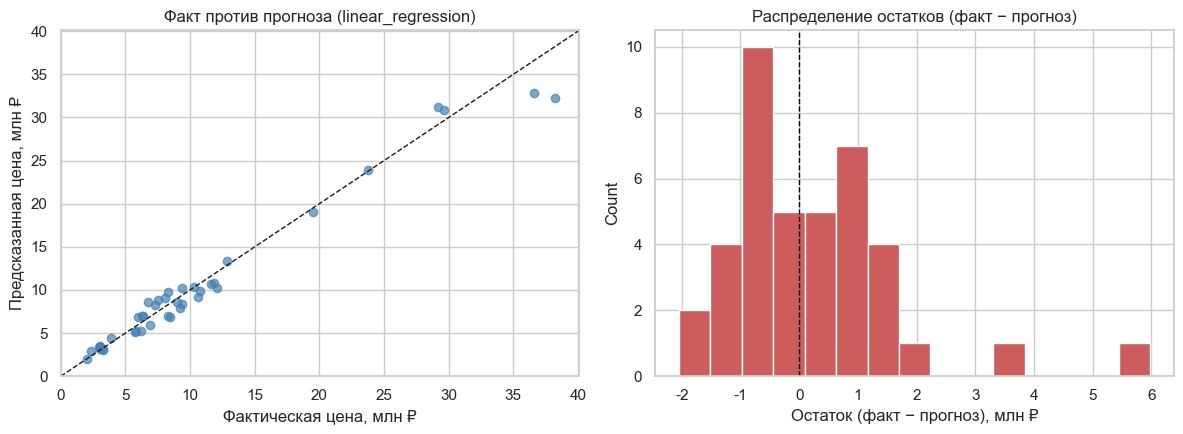

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

max_val = max(error_df["price_true"].max(), error_df["price_pred"].max()) / 1e6 * 1.05
axes[0].scatter(error_df["price_true"] / 1e6, error_df["price_pred"] / 1e6, alpha=0.7, color="steelblue")
axes[0].plot([0, max_val], [0, max_val], "k--", linewidth=1)
axes[0].set_xlim(0, max_val)
axes[0].set_ylim(0, max_val)
axes[0].set_xlabel("Фактическая цена, млн ₽")
axes[0].set_ylabel("Предсказанная цена, млн ₽")
axes[0].set_title(f"Факт против прогноза ({BEST_MODEL_NAME})")

axes[1].hist(error_df["residual"] / 1e6, bins=15, color="indianred", edgecolor="white")
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("Остаток (факт \u2212 прогноз), млн ₽")
axes[1].set_ylabel("Count")
axes[1].set_title("Распределение остатков (факт \u2212 прогноз)")

plt.tight_layout()
plt.savefig(ASSETS_DIR / "10_actual_vs_predicted_residuals.png", dpi=110, bbox_inches="tight")
plt.show()

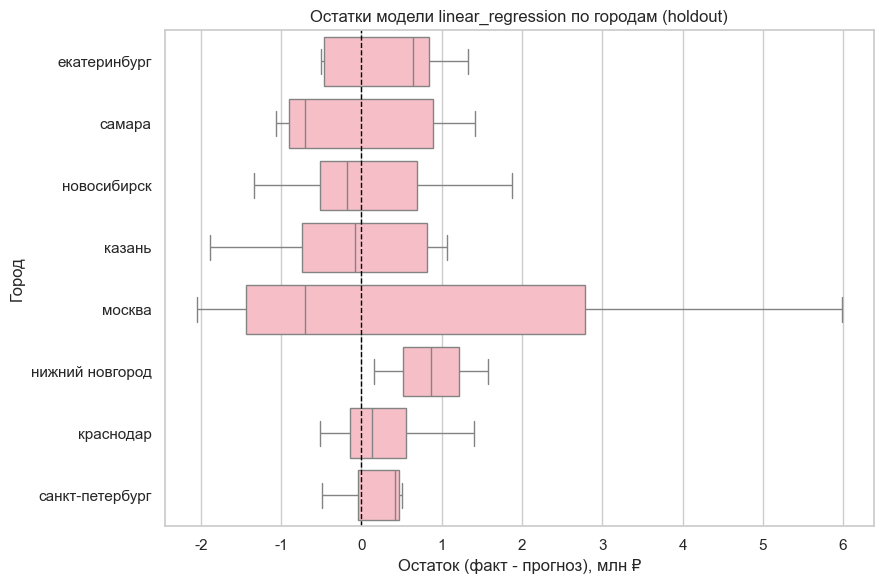

In [42]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(data=error_df, x="residual", y="city", ax=ax, color="lightpink")
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.xaxis.set_major_formatter(RUB_M_FORMATTER)
ax.set_xlabel("Остаток (факт - прогноз), млн ₽")
ax.set_ylabel("Город")
ax.set_title(f"Остатки модели {BEST_MODEL_NAME} по городам (holdout)")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "11_error_by_city.png", dpi=110, bbox_inches="tight")
plt.show()

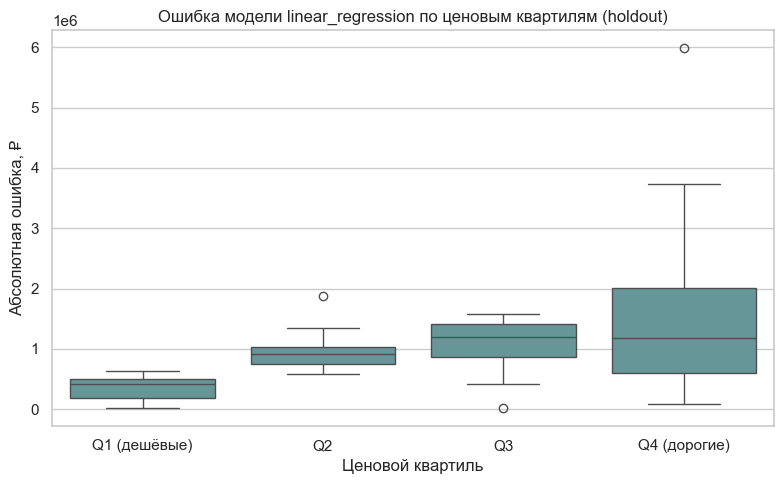

Средняя абсолютная ошибка (MAE) по квартилям цены:
                count       mean
price_quantile                  
Q1 (дешёвые)       10   354692.0
Q2                 10   985743.0
Q3                 10  1042161.0
Q4 (дорогие)       10  1795040.0


In [43]:
error_df["price_quantile"] = pd.qcut(error_df["price_true"], q=4, labels=["Q1 (дешёвые)", "Q2", "Q3", "Q4 (дорогие)"])

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=error_df, x="price_quantile", y="abs_error", ax=ax, color="cadetblue")
ax.set_xlabel("Ценовой квартиль")
ax.set_ylabel("Абсолютная ошибка, ₽")
ax.set_title(f"Ошибка модели {BEST_MODEL_NAME} по ценовым квартилям (holdout)")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "12_error_by_price_quantile.png", dpi=110, bbox_inches="tight")
plt.show()

print("Средняя абсолютная ошибка (MAE) по квартилям цены:")
print(error_df.groupby("price_quantile", observed=True)["abs_error"].agg(["count", "mean"]).round(0))

In [44]:
print("5 объектов с наибольшей абсолютной ошибкой (holdout):")
worst = error_df.sort_values("abs_error", ascending=False).head(5)
print(worst[["city", "price_true", "price_pred", "abs_error"]].round(0).to_string(index=False))

5 объектов с наибольшей абсолютной ошибкой (holdout):
       city  price_true  price_pred  abs_error
     москва  38193000.0  32209605.0  5983395.0
     москва  36597000.0  32858065.0  3738935.0
     москва  29199000.0  31246007.0  2047007.0
     казань   6768000.0   8650944.0  1882944.0
новосибирск  12116000.0  10234942.0  1881058.0


**Промежуточный вывод:** проверяем, не сконцентрированы ли ошибки в одном
городе или ценовом сегменте — если бы, например, ошибка систематически
росла для дорогих объектов (Q4), это указывало бы на необходимость
отдельной модели/трансформации для дорогого сегмента. На 40 holdout-строках
любые выводы здесь — иллюстративные, а не статистически надёжные (слишком
мало объектов на город/квартиль для формальных тестов).

## 22. Интерпретация: важность признаков (permutation importance)

Считаем permutation importance на holdout-выборке для лучшей модели —
метод, не зависящий от типа модели (в отличие от `feature_importances_`,
который есть только у деревьев), поэтому одинаково применим независимо от
того, какая модель оказалась лучшей.

**Почему не SHAP.** SHAP осознанно не используется в этом разделе:
(1) он потребовал бы добавления новой зависимости в
`requirements.txt`/`requirements-dev.txt`; (2) permutation importance уже
даёт модель-агностичную оценку важности, одинаково применимую ко всем 12
кандидатам раздела 17 (линейным и древесным), в отличие от
`feature_importances_`, доступного только для деревьев; (3) при 40
holdout-строках и в целом близком к линейному синтетическом датасете
(раздел 25) выгода от SHAP-взаимодействий признаков, скорее всего,
минимальна относительно веса новой зависимости. При появлении существенно
нелинейной модели на большем датасете к SHAP стоит вернуться.

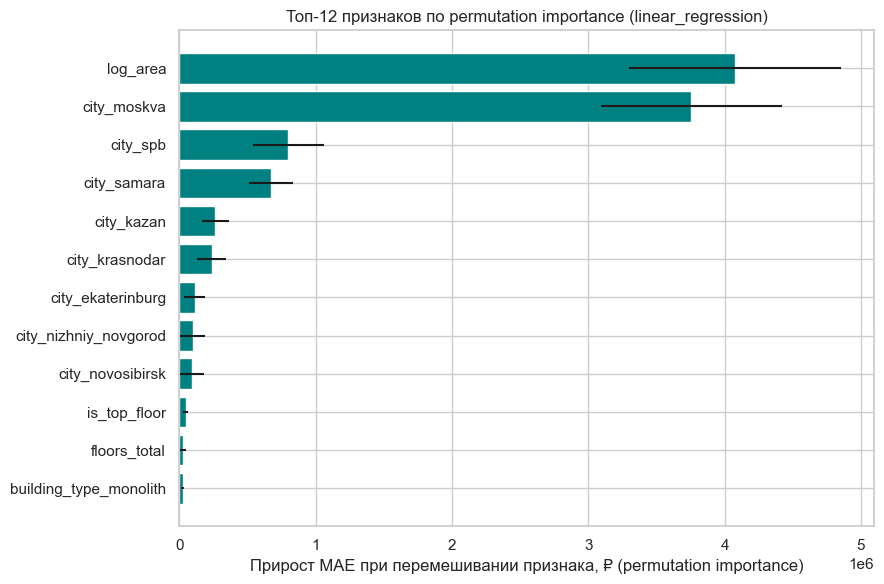

               feature  importance_mean  importance_std
              log_area       4075000.51       777582.57
           city_moskva       3755832.87       663133.71
              city_spb        799741.64       261648.01
           city_samara        673489.87       159959.10
            city_kazan        264920.98        98508.61
        city_krasnodar        236611.06       104144.44
     city_ekaterinburg        112851.33        77987.50
 city_nizhniy_novgorod         98113.11        93652.59
      city_novosibirsk         91704.08        88110.20
          is_top_floor         47615.38        18770.13
          floors_total         27830.23        20277.21
building_type_monolith         23811.42        14038.87


In [45]:
perm_result = permutation_importance(
    BEST_MODEL, X_test, y_test_rub, scoring="neg_mean_absolute_error",
    n_repeats=30, random_state=RANDOM_STATE, n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False)

top_n = 12
fig, ax = plt.subplots(figsize=(9, 6))
top_features = importance_df.head(top_n).iloc[::-1]
ax.barh(top_features["feature"], top_features["importance_mean"], xerr=top_features["importance_std"], color="teal")
ax.set_xlabel("Прирост MAE при перемешивании признака, ₽ (permutation importance)")
ax.set_title(f"Топ-{top_n} признаков по permutation importance ({BEST_MODEL_NAME})")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "13_permutation_importance.png", dpi=110, bbox_inches="tight")
plt.show()

print(importance_df.head(top_n).round(2).to_string(index=False))

**Промежуточный вывод:** ожидаемо доминируют `total_area`/`log_area`/
`rooms_x_area` и one-hot признаки города — это напрямую согласуется с
результатами статистических тестов (H1, H4, раздел 11) и с корреляционной
матрицей (раздел 10.10). Если бы важность распределялась случайно между
признаками без связи с этими выводами, это было бы поводом перепроверить
пайплайн на утечки или ошибки.

## 23. Проверка устойчивости

Два сигнала об устойчивости уже есть в таблице сравнения (раздел 19): CV
std для MAE/RMSE лучшей модели. Дополнительно — быстрый повторный прогон
лучшей модели с ДРУГИМ `random_state` разбиения (7 вместо 42), чтобы
показать чувствительность метрик к конкретному сплиту при таком маленьком
датасете.

In [46]:
cv_row_best = comparison_df.loc[comparison_df["model"] == BEST_MODEL_NAME].iloc[0]
print(f"CV MAE ({BEST_MODEL_NAME}):  {cv_row_best['cv_mae_mean']:,.0f} +/- {cv_row_best['cv_mae_std']:,.0f} RUB")
print(f"CV RMSE ({BEST_MODEL_NAME}): {cv_row_best['cv_rmse_mean']:,.0f} +/- {cv_row_best['cv_rmse_std']:,.0f} RUB")

CV MAE (linear_regression):  1,147,732 +/- 114,368 RUB
CV RMSE (linear_regression): 1,709,288 +/- 259,564 RUB


In [47]:
ALT_RANDOM_STATE = 7
X_train_alt, X_test_alt, y_train_alt, y_test_alt = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=ALT_RANDOM_STATE
)
y_train_alt_rub = np.expm1(y_train_alt)
y_test_alt_rub = np.expm1(y_test_alt)

from sklearn.base import clone
best_model_alt = clone(BEST_MODEL)
best_model_alt.fit(X_train_alt, y_train_alt_rub)
y_pred_alt = best_model_alt.predict(X_test_alt)

mae_alt = mean_absolute_error(y_test_alt_rub, y_pred_alt)
r2_alt = r2_score(y_test_alt_rub, y_pred_alt)

print(f"{BEST_MODEL_NAME} @ random_state=42: MAE={cv_row_best['holdout_mae']:,.0f} RUB, R2={cv_row_best['holdout_r2']:.3f}")
print(f"{BEST_MODEL_NAME} @ random_state={ALT_RANDOM_STATE}:  MAE={mae_alt:,.0f} RUB, R2={r2_alt:.3f}")
print(f"Относительная разница MAE: {abs(mae_alt - cv_row_best['holdout_mae']) / cv_row_best['holdout_mae']:.1%}")

linear_regression @ random_state=42: MAE=1,044,409 RUB, R2=0.972
linear_regression @ random_state=7:  MAE=1,219,736 RUB, R2=0.955
Относительная разница MAE: 16.8%


**Промежуточный вывод:** если MAE/R² заметно «плавают» между двумя
случайными сплитами — это прямое, честное свидетельство того, что 200
строк (40 holdout) слишком мало для стабильной точечной оценки качества
модели. Именно поэтому все метрики в этом ноутбуке сопровождаются
указанием объёма выборки, а формальный интервал (раздел про
`compute_residual_quantile_interval`, продакшн-код) называется
«оценочным диапазоном», а не статистическим доверительным интервалом.

## 24. Продакшн-контекст

Эта модель — не самоцель ноутбука, а часть более широкого демо-сервиса в
этом же репозитории (реализация не дублируется здесь, только ссылки):

- **FastAPI-сервис** (`api/main.py`, `api/schemas.py`) — принимает параметры
  квартиры через `POST /predict`, использует `src.inference.predictor.Predictor`
  для загрузки последнего артефакта из `models/` и построения вектора
  признаков, идентичного тренировочному (`_MODEL_FEATURES`).
- **Streamlit-дашборд** (`dashboard/app.py`) — форма ввода + визуализация
  прогноза, явно показывает пользователю бейдж DEMO/ML-режима и
  «оценочный диапазон» (не «доверительный интервал» — терминология
  специально исправлена, см. `src.models.trainer.compute_residual_quantile_interval`).
- **Обучение модели** — `scripts/run_model_training_real.py`, вызывается
  через `make train-demo` (явный флаг `--allow-synthetic`, пайплайн
  fail-closed по умолчанию — не обучится молча на синтетических данных).

Модель, обученная в этом ноутбуке, использует тот же класс `ModelTrainer`,
тот же `FeatureEngineer` и тот же протокол сохранения (`ModelTrainer.save()`
с тегом `synthetic`), поэтому воспроизводима вне ноутбука тем же кодом.

## 25. Ограничения

1. **Синтетические данные (главное ограничение).** Все числа в этом
   ноутбуке — MAE, RMSE, R², p-value, importance — описывают исключительно
   поведение функции `_generate_synthetic_data()`. Ни один результат нельзя
   использовать как утверждение о реальном рынке недвижимости РФ.
2. **Размер выборки.** 200 строк, 160 train / 40 holdout. Раздел 23
   (проверка устойчивости) показывает конкретную чувствительность метрик к
   выбору `random_state` — это не гипотетический риск, а измеренный эффект.
3. **Оценочный, а не статистический интервал.** `prediction_interval`
   (`compute_residual_quantile_interval`) калиброван на том же holdout, на
   котором считаются метрики качества — не на отдельной калибровочной
   выборке (для честного conformal-интервала данных банально не хватает).
4. **Ограниченная гранулярность геопризнака.** Есть только город (8
   категорий), нет района/координат — реальный рынок недвижимости
   значительно более гетерогенен внутри одного города.
5. **Макропризнаки (`key_rate`, `usd_rate`, `inflation_rate`,
   `rate_change_6m`)** в генераторе — иллюстративные константы, не результат
   живого обращения к API ЦБ РФ (см. `DATA_CARD.md`).
6. **`building_type`/H6 и этаж/H2-H3** не показали статистически
   устойчивого сигнала в этих данных — это не означает, что они
   нерелевантны в реальности, а лишь то, что синтетический генератор не
   закладывает для них выраженного эффекта.

## 26. Итоговые выводы

- Полный ML-пайплайн (аудит → очистка → EDA → статистика → признаки →
  проверка утечек → baseline → модели → интерпретация) воспроизведён в
  ноутбуке с переиспользованием production-кода (`DataCleaner`,
  `FeatureEngineer`, `ModelTrainer`), а не дублированием его логики.
- Единственный источник данных — синтетический генератор на 200 строк;
  это прозрачно обозначено в каждом разделе, где приводятся числа.
- Статистически устойчивые (после поправки на множественные сравнения)
  закономерности датасета — влияние города и площади на цену; это
  напрямую совпадает с формулой генератора и с тем, какие признаки
  оказались важны по permutation importance.
- Как минимум одна «настоящая» ML-модель превзошла все baseline-решения по
  holdout MAE в едином протоколе оценки (см. `reports/MODEL_EXPERIMENTS.md`
  и раздел 19) — но не все 7 протестированных ML-моделей одинаково хорошо
  обобщаются на этом маленьком датасете: модели на деревьях статистически
  более склонны к переобучению при 160 train-строках и не всегда
  превосходят простые линейные модели или baseline с городской
  группировкой (точная расстановка — в таблице раздела 19, не
  фиксированная заранее). Абсолютные цифры качества в любом случае не
  следует переносить на реальный рынок.
- Ноутбук является демонстрацией методологии (корректный сплит, честная
  статистика, единый протокол сравнения, явные проверки утечек), а не
  готовым к продакшену прогнозом цен на недвижимость.

## 27. Дорожная карта / следующие шаги

1. **Собрать реальные данные** — запустить `src/data_collection/cian_scraper.py`
   (или Selenium-версию) на нескольких страницах по каждому из 8 городов,
   сохранить в `data/raw/cian_listings*.csv`, затем прогнать
   `python scripts/run_feature_engineering_real.py` (без флага
   `--allow-synthetic` — реальные данные имеют приоритет и fail-closed
   проверка их не блокирует).
2. **Переобучить модель на реальных данных** —
   `python scripts/run_model_training_real.py` — артефакт автоматически
   получит `is_synthetic=False` и полную метаинформацию о происхождении.
3. **Повторить этот ноутбук на реальных данных** — большая часть кода
   (очистка, feature engineering, протокол оценки) переносится без
   изменений; понадобится пересмотреть статистические выводы и, вероятно,
   добавить временной сплит, если у реальных данных есть органический
   порядок по времени.
4. **Небольшая анонимизированная выборка** для публикации в репозитории
   (без точных адресов и URL) — см. `DATA_CARD.md`, раздел «What is NOT
   published and why».
5. **Отдельная калибровочная выборка** для честного prediction interval —
   возможно только при достаточном увеличении объёма данных (см.
   ограничение 3 в разделе 25).
6. **Учёт живых макропоказателей ЦБ РФ** через
   `src.preprocessing.economic_features` вместо иллюстративных констант.